# Lección 18.1 · Flujos reproducibles: grafos de trabajos, Snakemake y Nextflow

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-18-flujos-proyecto/18.1_snakemake_nextflow.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 18 — Flujos reproducibles y proyecto final** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Python básico; terminal; Lecciones 7.2 (BWA-MEM, samtools) y 9.2 (pipeline con bcftools) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué un *script* lineal no escala y **representar** un análisis como un **grafo acíclico dirigido**
   (DAG) de trabajos $G=(V,E)$.
2. **Programar desde cero** el **algoritmo de Kahn**, reproducir paso a paso el ejemplo del libro («Kahn sobre el flujo de
   tres muestras») y **demostrar** que detecta ciclos en tiempo $O(|V|+|E|)$.
3. **Evaluar** la regla de `make` para decidir qué rehacer y **predecir** cuántos trabajos se repiten al cambiar un archivo.
4. **Escribir y ejecutar** un *Snakefile* real (reglas, comodines, `expand`, `temp`, inferencia hacia atrás) que lleva
   las lecturas del clon del LTEE de Lenski del FASTQ a variantes anotadas; **dibujar** su DAG y **comprobar** la
   re-ejecución incremental.
5. **Traducir** el mismo flujo a **Nextflow** (procesos, canales de cola y de valor, `collect`) y **evitar** el error
   clásico $n_{\text{tareas}}=\min_i|c_i|$.
6. **Congelar** el entorno (Bioconda, contenedores, versiones exactas) y **calcular** claves de caché con *hash*.
7. **Acotar** el tiempo en paralelo con el trabajo $W$ y el camino crítico $S$, y **usar** las leyes de Amdahl, Gustafson y
   Karp-Flatt para decidir **cuántos núcleos pedir** (ejemplo del libro).
8. **Aplicar** las diez reglas de Sandve y los principios **FAIR** a un proyecto propio.

## 🗺️ Mapa de la clase

1. Por qué los *scripts* no escalan
2. Un análisis es un grafo acíclico dirigido (🔍 interactivo)
3. El algoritmo de Kahn, escrito desde cero (🎬 animación)
4. Dependencias por archivos: la herencia de Make
5. Snakemake: comodines e inferencia hacia atrás… y un *Snakefile* real con el clon del LTEE
6. Nextflow: procesos, canales y flujo de datos
7. Congelar el entorno: Bioconda y contenedores
8. Caché y reanudación con *hash*
9. Ejecución en clúster y en la nube
10. Paralelismo: trabajo, camino crítico y la ley de Amdahl (🎬 animación, 🔍 interactivo)
11. Buenas prácticas y principios FAIR
12. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Snakemake y Nextflow» del capítulo 18 del libro
> *Bioinformática Práctica*. Usamos los mismos símbolos ($G=(V,E)$, $\pi$, $d^-(v)$, $Q$, $\tau$, $\sigma$, $W$, $S$,
> $T_P$, $s$, $\psi$, $e$), el mismo grafo de 19 trabajos y reproducimos cifra por cifra sus ejemplos resueltos
> («Kahn sobre el flujo de tres muestras» y «¿Cuántos núcleos pedir para el proyecto?»). El notebook se puede seguir
> sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, time, math, heapq, hashlib, shutil, subprocess, collections
from collections import deque, defaultdict
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
warnings.filterwarnings("ignore", message="This figure was using a layout engine")

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

def sh(cmd, cwd=None, quiet=False, check=True):
    """Ejecuta una orden de la terminal, la muestra y devuelve (stdout, stderr, segundos)."""
    if not quiet:
        print("$", cmd)
    t0 = time.time()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    if check and p.returncode != 0:
        raise RuntimeError(p.stderr[-1500:])
    return p.stdout, p.stderr, time.time() - t0

print("Listo para la Lección 18.1")

Entorno listo ✔  |  Colab: False
Listo para la Lección 18.1


## 1. Por qué los *scripts* no escalan

Piense en la cocina de un restaurante a la hora punta. Un cocinero que prepara un plato en casa sigue la receta de arriba
abajo: pica, sofríe, hierve, sirve. En el restaurante esa estrategia sería un desastre. El jefe de cocina piensa la receta
como una **red de dependencias**: la salsa necesita el fondo, el fondo necesita los huesos tostados, el emplatado necesita
la salsa **y** la guarnición, que no dependen entre sí y se preparan a la vez en fogones distintos. Y hace tres cosas que el
cocinero doméstico no hace: **reparte en paralelo** lo que es independiente, **no repite** lo que ya está listo en la cámara
(la *mise en place*) y, cuando un plato vuelve porque la salsa salió mal, **rehace la salsa y todo lo que depende de ella**,
pero no vuelve a tostar los huesos. Un **gestor de flujos de trabajo** es ese jefe de cocina para nuestros análisis.

Llevemos esto al laboratorio. En los Módulos 6 a 9 seguimos al clon REL7179B del **experimento de evolución a largo plazo
(LTEE)** de Lenski (corrida SRR2584863): control de calidad, mapeo contra el ancestro REL606, marcado de duplicados, llamado
de variantes. Ahora imagine que el laboratorio secuencia **24 clones** de distintas generaciones y quiere, además,
secuencias consenso y un árbol. La forma más natural de automatizarlo es un *script* de `bash`:

```bash
for m in $(cat muestras.txt); do
    fastp -i datos/${m}_R1.fastq.gz -I datos/${m}_R2.fastq.gz -o limpio/${m}_R1.fq.gz -O limpio/${m}_R2.fq.gz
    bwa mem ref.fa limpio/${m}_R1.fq.gz limpio/${m}_R2.fq.gz | samtools sort -o mapeo/${m}.bam
    samtools markdup mapeo/${m}.bam mapeo/${m}.dedup.bam
done
bcftools mpileup -f ref.fa mapeo/*.dedup.bam | bcftools call -mv > variantes.vcf
```

Funciona para una muestra y una tarde. Con 24 muestras aparecen **cuatro defectos** que crecen con el problema:

| Defecto | Qué pasa en el laboratorio | Qué hace un gestor de flujos |
|---|---|---|
| **No sabe qué está hecho** | el mapeo de la muestra 17 falla por memoria; al relanzar se repiten las 16 anteriores | compara entradas y salidas y ejecuta sólo lo que falta |
| **No sabe qué es independiente** | los 24 mapeos van en serie aunque no dependen entre sí | lanza a la vez todo lo que está listo |
| **Mezcla lógica y entorno** | rutas absolutas, núcleos y "el `samtools` que haya" escondidos en el código | configuración, entornos y recursos separados de las reglas |
| **Falla en silencio** | sin `set -euo pipefail`, un error deja un archivo truncado que el paso siguiente consume | comprueba el código de salida y borra salidas incompletas |

La idea que resuelve los cuatro problemas a la vez: en lugar de describir **en qué orden** ejecutar los pasos, describimos
**qué produce cada paso a partir de qué**, y dejamos que un programa deduzca el orden, el paralelismo y lo que falta por
hacer (Wratten *et al.*, 2021).

> 🤔 **Antes de seguir, prediga.** Si el mapeo de la muestra 17 de 24 falla y relanzamos el *script* de arriba, ¿cuántos
> mapeos se repiten innecesariamente? ¿Y con un gestor que sabe qué archivos ya existen? (Respuesta: 16 y 0.)

## 2. Un análisis es un grafo acíclico dirigido

Empecemos por las palabras. Un **trabajo** (*job*) es la ejecución de un paso sobre entradas concretas: "mapear la muestra
A". Una **regla** es la plantilla de la que salen muchos trabajos: "mapear la muestra $\{m\}$". Si el trabajo $v$ lee un
archivo que escribe el trabajo $u$, dibujamos una flecha $u\to v$: $v$ **no puede empezar hasta que $u$ termine**.

**Ejemplo a mano.** Con una sola muestra A: `fastp_A` → `mapear_A` → `dedup_A`, y el índice `bwa_index` → `mapear_A`.
Son 4 trabajos y 3 flechas. Un orden válido es (`bwa_index`, `fastp_A`, `mapear_A`, `dedup_A`), y también
(`fastp_A`, `bwa_index`, `mapear_A`, `dedup_A`): hay varios órdenes, pero `mapear_A` siempre va después de sus dos
proveedores.

**Definición (grafo de trabajos).** El grafo de trabajos de un flujo es el grafo dirigido $G=(V,E)$ cuyos vértices $V$ son
los trabajos, con una arista $(u,v)\in E$ si algún archivo producido por $u$ es una entrada de $v$. Un **orden topológico**
de $G$ es una biyección $\pi:V\to\{1,\dots,|V|\}$ tal que

$$
(u,v)\in E \;\Longrightarrow\; \pi(u) < \pi(v). \tag{18.1}
$$

| Símbolo | Significado |
|---|---|
| $V,\ E$ | conjunto de trabajos y de dependencias (aristas del productor al consumidor) |
| $(u,v)$ | arista: $v$ no puede empezar hasta que $u$ termine |
| $\pi(v)$ | posición de $v$ en una ejecución en serie que respete todas las dependencias |
| $\lvert V\rvert,\ \lvert E\rvert$ | número de trabajos y de dependencias |

El flujo que usaremos como hilo conductor es el del libro, con **tres muestras** (A, B, C): `fastp` (control de calidad),
`mapear` (BWA-MEM), `dedup` (duplicados) y `consenso` se instancian una vez por muestra; `bwa_index`, `llamar` (llamado
conjunto), `filtrar`, `anotar`, `filogenia` y `multiqc`, una sola vez. El vértice `all` no ejecuta nada: sólo declara los
archivos finales que queremos. Construyámoslo con diccionarios de Python, sin bibliotecas de grafos.

In [2]:
# Orden de las reglas en el Snakefile del libro (sirve para desempatar) y color de cada regla
RULES = ["bwa_index", "fastp", "mapear", "dedup", "llamar", "filtrar", "anotar",
         "consenso", "filogenia", "multiqc", "all"]
RULE_COLOR = {"bwa_index": "#898781", "fastp": ec.BLUE, "mapear": ec.AQUA, "dedup": ec.GREEN,
              "llamar": ec.ORANGE, "filtrar": ec.YELLOW, "anotar": ec.MAGENTA, "consenso": ec.VIOLET,
              "filogenia": ec.RED, "multiqc": "#104281", "all": "#0b0b0b",
              "region": ec.ORANGE, "concat": "#b8302f"}

def duration(rule, n):
    """Minutos (ilustrativos, los del libro) de cada trabajo con n muestras."""
    return {"bwa_index": 2, "fastp": 3, "mapear": 12, "dedup": 4, "consenso": 1, "llamar": 6 + 3 * n,
            "filtrar": 1, "anotar": 2, "filogenia": 4 + 2 * n, "multiqc": 1, "all": 0,
            "region": 6 + 3 * n, "concat": 1}[rule]

def rule_of(v):
    return "bwa_index" if v == "bwa_index" else v.split("_")[0]

def build_dag(samples, regions=0):
    """Grafo de trabajos del flujo del libro: dict {trabajo: [sucesores]} y dict de duraciones.
    regions > 0 divide el llamado conjunto en regiones del genoma (scatter-gather)."""
    succ = defaultdict(list)
    def edge(u, v):
        succ[u].append(v)
        succ.setdefault(v, [])
    n = len(samples)
    for m in samples:
        edge(f"fastp_{m}", f"mapear_{m}")
        edge("bwa_index", f"mapear_{m}")
        edge(f"mapear_{m}", f"dedup_{m}")
        edge(f"fastp_{m}", "multiqc")
        edge("filtrar", f"consenso_{m}")
        edge(f"consenso_{m}", "filogenia")
        if regions:
            for r in range(regions):
                edge(f"dedup_{m}", f"region_{r}")
        else:
            edge(f"dedup_{m}", "llamar")
    if regions:
        for r in range(regions):
            edge(f"region_{r}", "concat")
        edge("concat", "filtrar")
    else:
        edge("llamar", "filtrar")
    edge("filtrar", "anotar")
    for v in ("anotar", "filogenia", "multiqc"):
        edge(v, "all")
    t = {v: (duration("llamar", n) / regions if rule_of(v) == "region" else duration(rule_of(v), n)) for v in succ}
    return dict(succ), t

def canonical(nodes):
    """Orden canónico: primero por la posición de la regla en el Snakefile, luego por nombre."""
    return sorted(nodes, key=lambda v: (RULES.index(rule_of(v)), v))

def predecessors(succ):
    pred = {v: [] for v in succ}
    for u, vs in succ.items():
        for v in vs:
            pred[v].append(u)
    return pred

SUCC, T3 = build_dag(["A", "B", "C"])
PRED = predecessors(SUCC)
NODES = canonical(SUCC)
n_edges = sum(len(v) for v in SUCC.values())
print(f"|V| = {len(SUCC)} trabajos, |E| = {n_edges} aristas")
for v in NODES:
    print(f"  {v:11s} → {', '.join(canonical(SUCC[v])) or '(nada: es el objetivo final)'}")

|V| = 19 trabajos, |E| = 26 aristas
  bwa_index   → mapear_A, mapear_B, mapear_C
  fastp_A     → mapear_A, multiqc
  fastp_B     → mapear_B, multiqc
  fastp_C     → mapear_C, multiqc
  mapear_A    → dedup_A
  mapear_B    → dedup_B
  mapear_C    → dedup_C
  dedup_A     → llamar
  dedup_B     → llamar
  dedup_C     → llamar
  llamar      → filtrar
  filtrar     → anotar, consenso_A, consenso_B, consenso_C
  anotar      → all
  consenso_A  → filogenia
  consenso_B  → filogenia
  consenso_C  → filogenia
  filogenia   → all
  multiqc     → all
  all         → (nada: es el objetivo final)


> 🔎 **Qué observamos.** 19 trabajos y 26 aristas, como en la figura 18.1 del libro. Las aristas "muchos a uno"
> (`dedup_A`, `dedup_B`, `dedup_C` → `llamar`) son las que hacen que el llamado sea **conjunto**: necesita a todas las
> muestras. Y las "uno a muchos" (`bwa_index` → tres mapeos) son las que ahorran trabajo: el índice se construye una vez.

### ¿Cuándo existe un orden topológico?

**Teorema.** Un grafo dirigido finito admite un orden topológico **si y sólo si** no contiene ciclos dirigidos.

*Idea de la demostración.* ($\Rightarrow$) Un ciclo $v_1\to v_2\to\cdots\to v_k\to v_1$ exigiría
$\pi(v_1)<\pi(v_2)<\cdots<\pi(v_k)<\pi(v_1)$: imposible. ($\Leftarrow$) Primero un **lema**: todo grafo finito acíclico no
vacío tiene una **fuente**, un vértice sin aristas entrantes (si todo vértice tuviera un predecesor podríamos caminar hacia
atrás sin fin; con $|V|$ vértices, tras $|V|+1$ pasos repetiríamos uno, y el tramo entre las dos visitas sería un ciclo).
Luego, por inducción: tomamos una fuente $s$, le damos $\pi(s)=1$, la quitamos y ordenamos el resto. $\square$

La demostración **contiene un algoritmo**: "toma una fuente y quítala", repetido. Para verlo, dibujemos el grafo con cada
trabajo en la columna de su **ronda**: la ronda 1 son las fuentes; la ronda $k$, los trabajos cuyos predecesores están
todos en rondas anteriores (la longitud del camino más largo que llega a ellos).

rondas = 8 · ancho por ronda = [4, 4, 3, 1, 1, 4, 1, 1]


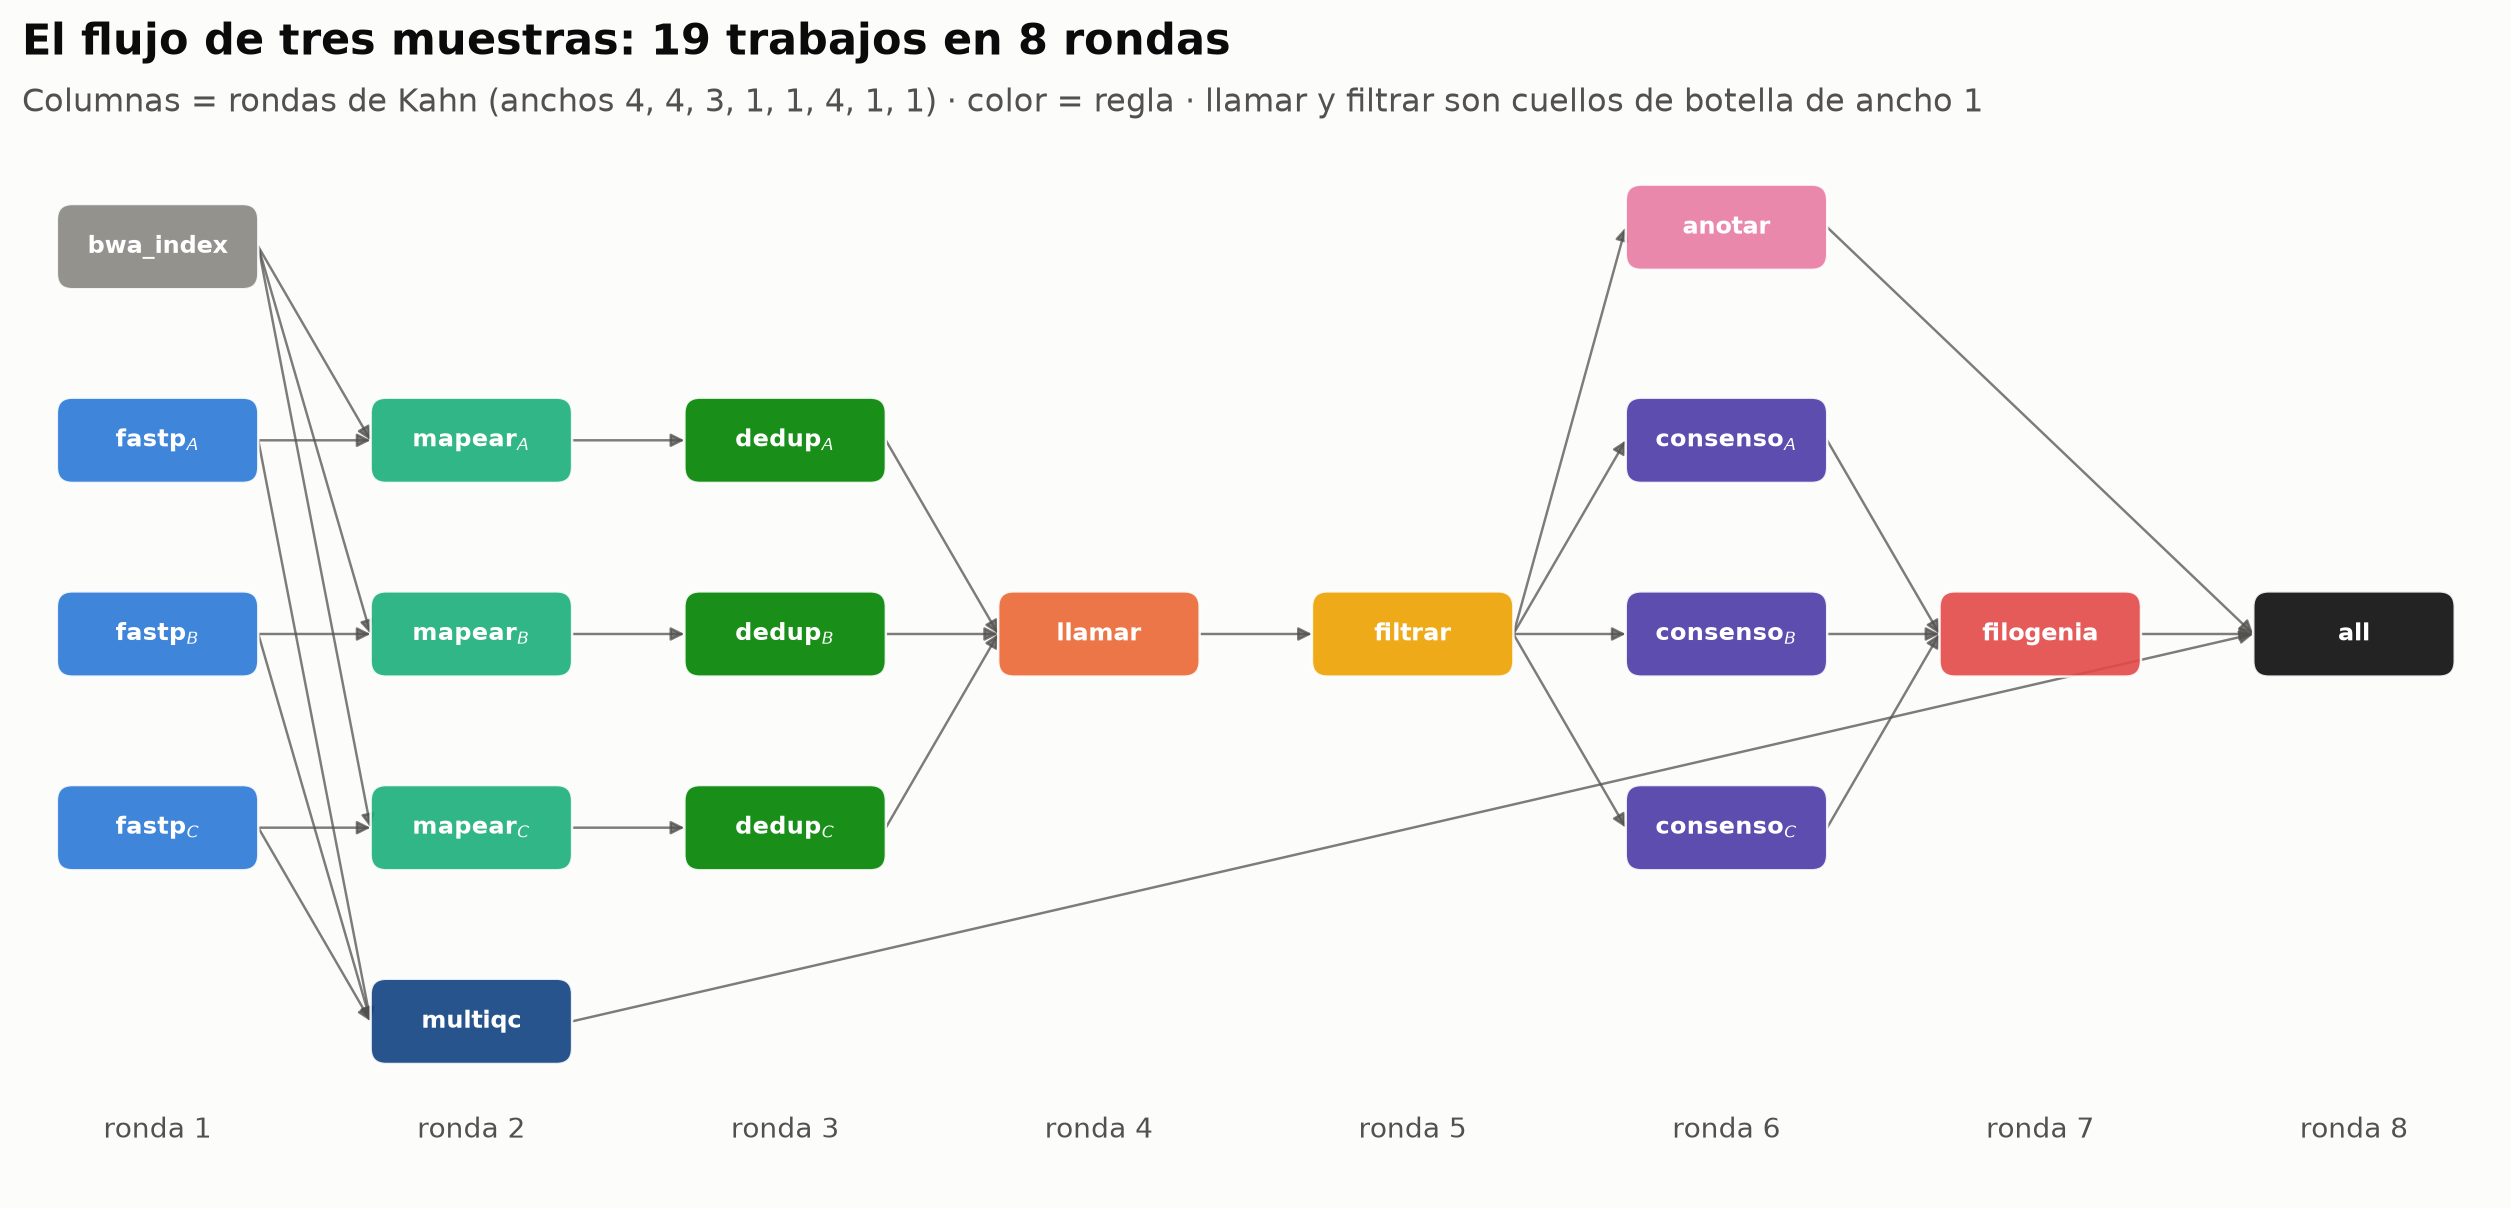

In [3]:
def levels(succ):
    """Ronda de cada trabajo = 1 + ronda máxima de sus predecesores (fuentes: ronda 1)."""
    pred = predecessors(succ)
    lev = {}
    def f(v):
        if v not in lev:
            lev[v] = 1 + max((f(u) for u in pred[v]), default=0)
        return lev[v]
    for v in succ:
        f(v)
    return lev

LEV = levels(SUCC)
L = max(LEV.values())
widths = [sum(1 for v in SUCC if LEV[v] == k) for k in range(1, L + 1)]
print("rondas =", L, "· ancho por ronda =", widths)

# Posiciones para dibujar: x = ronda, y = fila fija por muestra (la misma disposición que el libro)
ROW = {"A": 0.5, "B": -0.5, "C": -1.5}
YPOS = {"bwa_index": 1.5, "multiqc": -2.5, "anotar": 1.6}
POS = {}
for v in SUCC:
    suffix = v[len(rule_of(v)) + 1:]
    POS[v] = (1.62 * (LEV[v] - 1), YPOS.get(v, ROW.get(suffix, -0.5)))

def short(v):
    r = rule_of(v)
    s = v[len(r) + 1:]
    return f"{r}$_{{{s}}}$" if s else r

def draw_dag(ax, highlight=None, faded=(), labels=None, edge_alpha=1.0, fontsize=8):
    """Dibuja el DAG del libro. highlight: {trabajo: color de borde}; faded: trabajos atenuados."""
    highlight = highlight or {}
    for u in SUCC:
        for v in SUCC[u]:
            (x0, y0), (x1, y1) = POS[u], POS[v]
            a = 0.25 if (u in faded or v in faded) else 0.75 * edge_alpha
            ax.add_patch(FancyArrowPatch((x0 + 0.52, y0), (x1 - 0.52, y1), arrowstyle="-|>", mutation_scale=9,
                                         color="#52514e", lw=0.8, alpha=a, shrinkA=0, shrinkB=0,
                                         connectionstyle="arc3,rad=0.0"))
    for v, (x, y) in POS.items():
        col = RULE_COLOR[rule_of(v)]
        fa = 0.25 if v in faded else 1.0
        ax.add_patch(FancyBboxPatch((x - 0.5, y - 0.2), 1.0, 0.4, boxstyle="round,pad=0.02,rounding_size=0.08",
                                    fc=col, ec=highlight.get(v, "white"), lw=3 if v in highlight else 0.8,
                                    alpha=0.9 * fa if v not in highlight else 1, zorder=3))
        txt = labels[v] if labels and v in labels else short(v)
        ax.text(x, y, txt, ha="center", va="center", fontsize=fontsize, zorder=4, fontweight="bold",
                color="white" if fa == 1 else "#52514e")
    for k in range(1, L + 1):
        ax.text(1.62 * (k - 1), -3.1, f"ronda {k}", ha="center", fontsize=9, color="#52514e")
    ax.set_xlim(-0.7, 1.62 * (L - 1) + 0.7)
    ax.set_ylim(-3.35, 2.05)
    ax.set_aspect("equal")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(13, 5.6))
draw_dag(ax)
ec.title(ax, "El flujo de tres muestras: 19 trabajos en 8 rondas",
         "Columnas = rondas de Kahn (anchos 4, 4, 3, 1, 1, 4, 1, 1) · color = regla · llamar y filtrar son cuellos de botella de ancho 1")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Las columnas son las **rondas**: todos los trabajos de una columna son independientes entre sí y
> pueden ejecutarse a la vez. Los anchos son $4,4,3,1,1,4,1,1$. Hay dos **cuellos de botella** de ancho 1, `llamar` y
> `filtrar`: el llamado conjunto necesita **todas** las muestras y por ahí pasa todo el flujo. El ancho máximo, 4, es el
> número de núcleos a partir del cual este flujo ya no aprovecha más paralelismo (lo precisaremos en la sección 10).

Explore el grafo en la versión interactiva: al pasar el ratón sobre cada trabajo verá su regla, su **grado de entrada**
$d^-(v)$ (cuántas dependencias tiene), su ronda, su duración ilustrativa y **cuántos trabajos habría que rehacer** si
cambiara (sección 4).

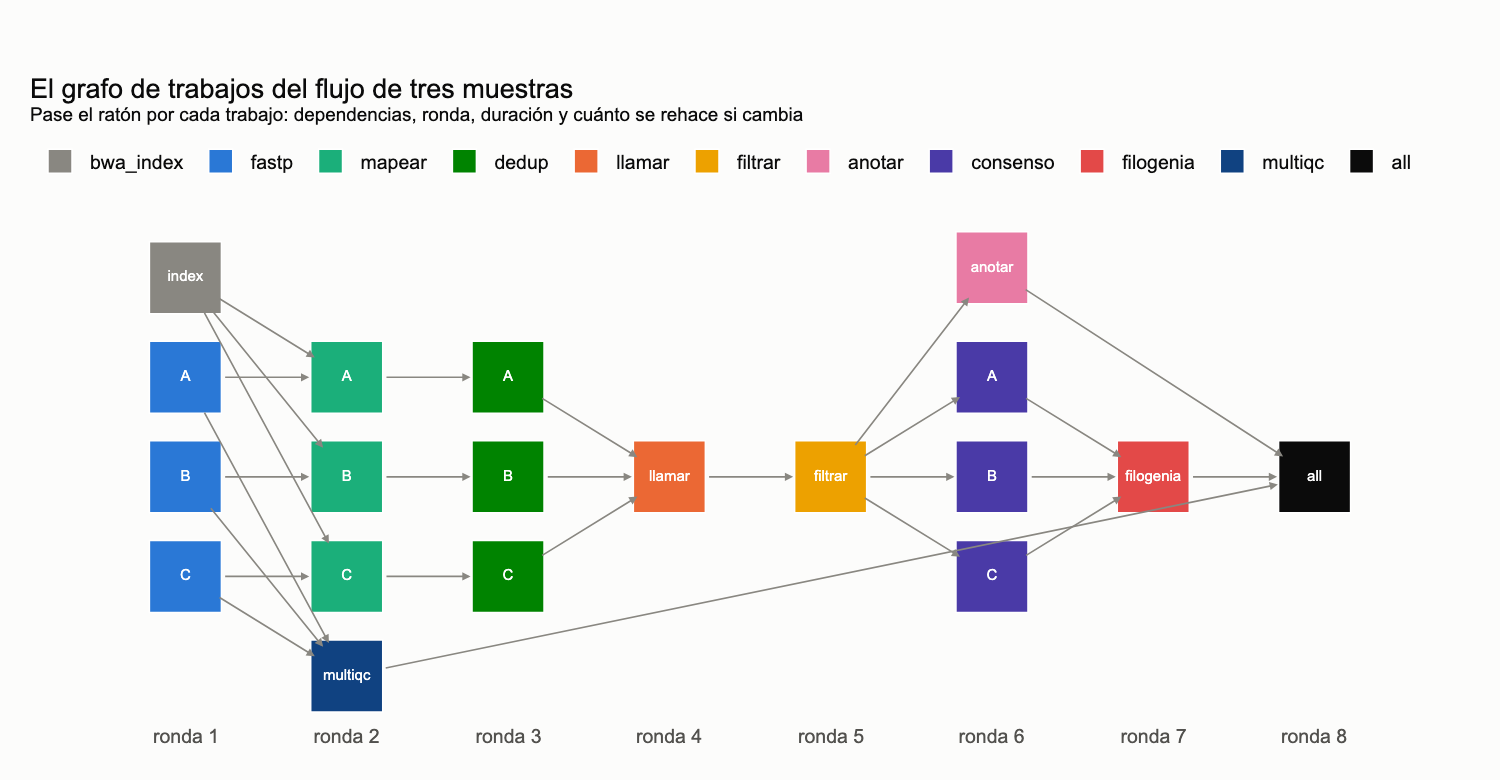

In [4]:
def descendants(succ, v):
    """Todos los trabajos alcanzables desde v (búsqueda en anchura)."""
    seen, q = set(), deque([v])
    while q:
        for u in succ[q.popleft()]:
            if u not in seen:
                seen.add(u)
                q.append(u)
    return seen

fig = go.Figure()
for u in SUCC:            # aristas como flechas que empiezan y terminan en el borde de cada caja
    for v in SUCC[u]:
        fig.add_annotation(x=POS[v][0], y=POS[v][1], ax=POS[u][0], ay=POS[u][1],
                           xref="x", yref="y", axref="x", ayref="y", showarrow=True, standoff=25, startstandoff=25,
                           arrowhead=2, arrowsize=1, arrowwidth=1.1, arrowcolor="#898781", text="")
for r in RULES:
    vs = [v for v in NODES if rule_of(v) == r]
    hover = []
    for v in vs:
        d = descendants(SUCC, v) - {"all"}
        hover.append(f"<b>{v}</b><br>regla: {r}<br>d⁻(v) = {len(PRED[v])} dependencias: "
                     f"{', '.join(PRED[v]) or '— (fuente)'}<br>ronda {LEV[v]}<br>duración ilustrativa: {T3[v]} min"
                     f"<br>si cambia, se rehacen {0 if v == 'all' else 1 + len(d)} de 18 trabajos reales")
    fig.add_trace(go.Scatter(x=[POS[v][0] for v in vs], y=[POS[v][1] for v in vs], mode="markers+text",
                             marker=dict(size=48, color=RULE_COLOR[r], symbol="square", line=dict(color="white", width=1)),
                             text=[v.split("_")[-1] if rule_of(v) != v else r.replace("bwa_", "") for v in vs],
                             textfont=dict(color="white", size=10), name=r, hovertext=hover, hoverinfo="text"))
for k in range(1, L + 1):
    fig.add_annotation(x=1.62 * (k - 1), y=-3.1, text=f"ronda {k}", showarrow=False, font=dict(color="#52514e"))
fig.update_layout(title="El grafo de trabajos del flujo de tres muestras<br><sup>Pase el ratón por cada trabajo: "
                        "dependencias, ronda, duración y cuánto se rehace si cambia</sup>",
                  xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor="x"), height=520,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=20, r=20, b=20))
fig.show()

## 3. El algoritmo de Kahn, escrito desde cero

"Toma una fuente y quítala" es correcto, pero buscar fuentes recorriendo todo el grafo en cada paso cuesta $O(|V|^2)$.
Kahn (1962), que ordenaba las redes de actividades de proyectos de ingeniería (redes PERT), lo resolvió con contabilidad.

**La observación clave.** Sea $d^-(v)$ el **grado de entrada** de $v$: cuántas aristas llegan a $v$. Quitar una fuente $s$
sólo cambia el grado de sus sucesores, y cada uno pierde **exactamente una** unidad. Así que las únicas fuentes **nuevas**
que pueden aparecer son sucesores de $s$ cuyo grado acaba de llegar a cero. Es como una lista de espera en la que cada
trabajo lleva la cuenta de cuántos "permisos" le faltan; cuando le llega el último, pasa a la fila de listos.

1. Calcular $d^-(v)$ para todo $v$ recorriendo una vez las aristas. Poner en una cola $Q$ todos los $v$ con $d^-(v)=0$.
2. Mientras $Q$ no esté vacía: sacar $v$ de $Q$, añadirlo al orden y, para cada sucesor $u$, hacer $d^-(u)\leftarrow d^-(u)-1$;
   si llega a 0, añadir $u$ a $Q$.
3. Si al vaciarse $Q$ el orden tiene menos de $|V|$ vértices, **el grafo tiene un ciclo**.

**Teorema (corrección y coste).** En todo momento $d^-(v)$ es el número de predecesores de $v$ que aún no están en el orden,
y $Q$ contiene exactamente los vértices no ordenados cuyos predecesores ya fueron ordenados. Por tanto el orden cumple
(18.1), si $G$ es acíclico se ordenan los $|V|$ vértices, si sobran vértices éstos contienen un ciclo, y

$$
T_{\text{Kahn}} = O\big(|V| + |E|\big). \tag{18.2}
$$

| Símbolo | Significado |
|---|---|
| $d^-(v)$ | grado de entrada "residual": dependencias de $v$ todavía pendientes |
| $Q$ | cola de trabajos **listos** (todas sus dependencias satisfechas) |
| $T_{\text{Kahn}}$ | número de operaciones elementales del algoritmo |

El coste es lineal porque cada arista se recorre una vez al calcular los grados y se "consume" una vez cuando sale su
origen, y cada vértice entra y sale de $Q$ a lo sumo una vez. Éste es el programa del libro (`kahn.py`), tal cual:

In [5]:
def orden_topologico(sucesores):
    """Kahn. sucesores = {nodo: [hijos]}; error si hay un ciclo."""
    grado = {v: 0 for v in sucesores}
    for hijos in sucesores.values():
        for u in hijos:
            grado[u] = grado.get(u, 0) + 1
    cola = deque(v for v, g in grado.items() if g == 0)
    orden = []
    while cola:
        v = cola.popleft()
        orden.append(v)
        for u in sucesores.get(v, []):
            grado[u] -= 1
            if grado[u] == 0:
                cola.append(u)
    if len(orden) < len(grado):                 # teorema, punto (iii)
        resto = [v for v, g in grado.items() if g > 0]
        raise ValueError(f"ciclo entre: {resto}")
    return orden

toy = {"bwa_index": ["mapear_A"], "fastp_A": ["mapear_A"], "mapear_A": ["dedup_A"], "dedup_A": []}
print("Ejemplo a mano (una muestra):", orden_topologico(toy))

Ejemplo a mano (una muestra): ['bwa_index', 'fastp_A', 'mapear_A', 'dedup_A']


### Ejemplo del libro: «Kahn sobre el flujo de tres muestras»

Primero, **a mano**, los grados de entrada iniciales: $d^-=0$ para `bwa_index` y los tres `fastp`; $d^-=2$ para cada
`mapear` (índice y lecturas limpias); $d^-=1$ para cada `dedup`, para `filtrar`, `anotar` y cada `consenso`; y $d^-=3$
para `llamar`, `multiqc`, `filogenia` y `all`. La suma es

$$4\cdot 0+3\cdot 2+3\cdot1+3+1+1+3\cdot1+3+3+3=26=|E|,$$

como debe ser: cada arista aporta exactamente una unidad a un grado de entrada. En el paso 1 sale `bwa_index`: sus tres
sucesores bajan de 2 a 1 y ninguno se libera. En el paso 2 sale `fastp_A`: `mapear_A` baja a 0 y entra en la cola, mientras
que `multiqc` baja de 3 a 2.

> 🤔 **Antes de ejecutar, prediga.** ¿En qué paso entra `multiqc` en la cola? ¿Y `llamar`? (Pista: `multiqc` espera a los
> tres `fastp`; `llamar`, a los tres `dedup`.)

Ahora, la versión **instrumentada** del mismo algoritmo, que además anota qué sale, qué se libera y cómo queda la cola en
cada paso. Desempatamos como el libro: cola FIFO y el orden de las reglas en el *Snakefile*.

In [6]:
def kahn_trace(succ):
    """Kahn con cola FIFO; devuelve el orden, la traza [(sale, liberados, cola, grados)] y los grados iniciales."""
    pred = predecessors(succ)
    indeg = {v: len(pred[v]) for v in succ}
    indeg0 = dict(indeg)
    order_key = {v: i for i, v in enumerate(canonical(succ))}
    Q = deque(v for v in canonical(succ) if indeg[v] == 0)
    order, trace = [], [(None, [], list(Q), dict(indeg))]
    while Q:
        v = Q.popleft()
        order.append(v)
        freed = []
        for u in sorted(succ[v], key=order_key.get):
            indeg[u] -= 1
            if indeg[u] == 0:
                Q.append(u)
                freed.append(u)
        trace.append((v, freed, list(Q), dict(indeg)))
    if len(order) < len(succ):
        raise ValueError("hay un ciclo")
    return order, trace, indeg0

ORDER, TRACE, INDEG0 = kahn_trace(SUCC)
print("grados de entrada iniciales:", {v: INDEG0[v] for v in NODES})
print("suma de grados =", sum(INDEG0.values()), "= |E|\n")
rows = [{"paso": i, "sale de Q": v or "", "grado llega a 0": ", ".join(fr) or "—",
         "cola Q tras el paso": ", ".join(q) or "(vacía)"} for i, (v, fr, q, _) in enumerate(TRACE)]
pd.set_option("display.max_colwidth", 80)
display(pd.DataFrame(rows).set_index("paso"))
assert ORDER.index("multiqc") == 7 and ORDER[10] == "dedup_C" and ORDER[-1] == "all"

grados de entrada iniciales: {'bwa_index': 0, 'fastp_A': 0, 'fastp_B': 0, 'fastp_C': 0, 'mapear_A': 2, 'mapear_B': 2, 'mapear_C': 2, 'dedup_A': 1, 'dedup_B': 1, 'dedup_C': 1, 'llamar': 3, 'filtrar': 1, 'anotar': 1, 'consenso_A': 1, 'consenso_B': 1, 'consenso_C': 1, 'filogenia': 3, 'multiqc': 3, 'all': 3}
suma de grados = 26 = |E|



,sale de Q,grado llega a 0,cola Q tras el paso
paso,,,
0,,—,"bwa_index, fastp_A, fastp_B, fastp_C"
1,bwa_index,—,"fastp_A, fastp_B, fastp_C"
2,fastp_A,mapear_A,"fastp_B, fastp_C, mapear_A"
3,fastp_B,mapear_B,"fastp_C, mapear_A, mapear_B"
4,fastp_C,"mapear_C, multiqc","mapear_A, mapear_B, mapear_C, multiqc"
5,mapear_A,dedup_A,"mapear_B, mapear_C, multiqc, dedup_A"
6,mapear_B,dedup_B,"mapear_C, multiqc, dedup_A, dedup_B"
7,mapear_C,dedup_C,"multiqc, dedup_A, dedup_B, dedup_C"
8,multiqc,—,"dedup_A, dedup_B, dedup_C"


> 🔎 **Qué observamos.** La tabla coincide fila por fila con la figura 18.2 del libro. `mapear_A` sólo se libera en el
> paso 2, cuando ya salieron sus **dos** predecesores; `multiqc` entra en la cola en el paso 4 (tras los tres `fastp`);
> `llamar`, en el paso 11 (tras los tres `dedup`). La última columna es, literalmente, **la lista de trabajos que un
> planificador podría lanzar en ese instante**. En el paso 19 sale `all` y la cola queda vacía con los 19 trabajos
> ordenados. Comprobemos el orden contra la definición (18.1) y veamos la animación de Kahn "pelando" el grafo.

In [7]:
pi = {v: i + 1 for i, v in enumerate(ORDER)}
bad = [(u, v) for u in SUCC for v in SUCC[u] if not pi[u] < pi[v]]
print("aristas que violan π(u) < π(v):", bad or "ninguna ✔")
print("¿coincide con orden_topologico() del libro?", ORDER == orden_topologico({v: canonical(SUCC[v]) for v in NODES}))

aristas que violan π(u) < π(v): ninguna ✔
¿coincide con orden_topologico() del libro? True


![Algoritmo de Kahn sobre el flujo de tres muestras: cada trabajo muestra su grado de entrada residual d⁻(v); en amarillo, la cola Q de trabajos listos; en rojo, el que sale; en gris, los ya ordenados con su posición π(v).](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-18-flujos-proyecto/18.1_kahn.gif)

*Algoritmo de Kahn sobre el flujo de tres muestras: cada trabajo muestra su grado de entrada residual d⁻(v); en amarillo, la cola Q de trabajos listos; en rojo, el que sale; en gris, los ya ordenados con su posición π(v).*

In [8]:
fig, ax = plt.subplots(figsize=(12.5, 6.2))

def update(k):
    ax.clear()
    v, freed, Q, indeg = TRACE[k]
    done = set(ORDER[:k])
    labels = {}
    for u in SUCC:
        labels[u] = f"π={pi[u]}" if u in done and u != v else f"{short(u)}\nd⁻={indeg[u]}"
    hl = {u: ec.YELLOW for u in Q}
    if v:
        hl[v] = "#d03b3b"
    draw_dag(ax, highlight=hl, faded=done - {v}, labels=labels)
    msg = "paso 0: la cola contiene las cuatro fuentes" if not v else \
          f"paso {k}: sale {v}" + (f" · se liberan {', '.join(freed)}" if freed else " · no se libera nadie")
    ec.title(ax, "Kahn pela el grafo fuente a fuente", msg)
    ax.text(0, 2.0, "Q = [" + ", ".join(Q) + "]", fontsize=9, color="#52514e", va="bottom")

ec.animate(fig, update, frames=len(TRACE), interval=900, name="18.1_kahn")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Rondas y detección de ciclos

Si en lugar de sacar de uno en uno procesamos **rondas completas** (todas las fuentes de una vez), obtenemos 8 rondas de
anchos $4,4,3,1,1,4,1,1$: las columnas de la figura. Y el punto (iii) del teorema da **gratis** la detección de ciclos.
Supongamos que alguien escribe por error una regla que hace depender el mapeo de A del VCF filtrado (por ejemplo, para
"recalibrar"): `filtrar` → `mapear_A`. Todo gestor de flujos rechaza ese flujo **antes de ejecutar nada**:

In [9]:
def kahn_rounds(succ):
    pred = predecessors(succ)
    indeg = {v: len(pred[v]) for v in succ}
    frontier = [v for v in canonical(succ) if indeg[v] == 0]
    rounds = []
    while frontier:
        rounds.append(frontier)
        nxt = []
        for v in frontier:
            for u in succ[v]:
                indeg[u] -= 1
                if indeg[u] == 0:
                    nxt.append(u)
        frontier = canonical(nxt)
    return rounds

R = kahn_rounds(SUCC)
print("anchos por ronda:", [len(r) for r in R])
for i, r in enumerate(R, 1):
    print(f"  ronda {i}: {', '.join(r)}")

cyclic = {u: list(vs) for u, vs in SUCC.items()}
cyclic["filtrar"] = cyclic["filtrar"] + ["mapear_A"]
try:
    orden_topologico(cyclic)
except ValueError as err:
    print("\n❌", err)

anchos por ronda: [4, 4, 3, 1, 1, 4, 1, 1]
  ronda 1: bwa_index, fastp_A, fastp_B, fastp_C
  ronda 2: mapear_A, mapear_B, mapear_C, multiqc
  ronda 3: dedup_A, dedup_B, dedup_C
  ronda 4: llamar
  ronda 5: filtrar
  ronda 6: anotar, consenso_A, consenso_B, consenso_C
  ronda 7: filogenia
  ronda 8: all

❌ ciclo entre: ['mapear_A', 'dedup_A', 'filtrar', 'consenso_A', 'filogenia', 'llamar', 'consenso_B', 'consenso_C', 'anotar', 'all']


> 🔎 **Qué observamos.** Los trabajos que quedan con grado residual positivo son exactamente el ciclo
> (`mapear_A` → `dedup_A` → `llamar` → `filtrar` → `mapear_A`) **y todo lo que cuelga de él**. Snakemake diría
> `CyclicGraphException`; Nextflow no permite siquiera escribirlo, porque un canal no puede alimentar a un proceso anterior.

### ¿De verdad es lineal? Un experimento

La ecuación (18.2) promete que el tiempo crece como $|V|+|E|$. Medimos `orden_topologico` sobre grafos acíclicos
aleatorios (cada vértice apunta a unos pocos vértices posteriores, lo que garantiza que no haya ciclos).

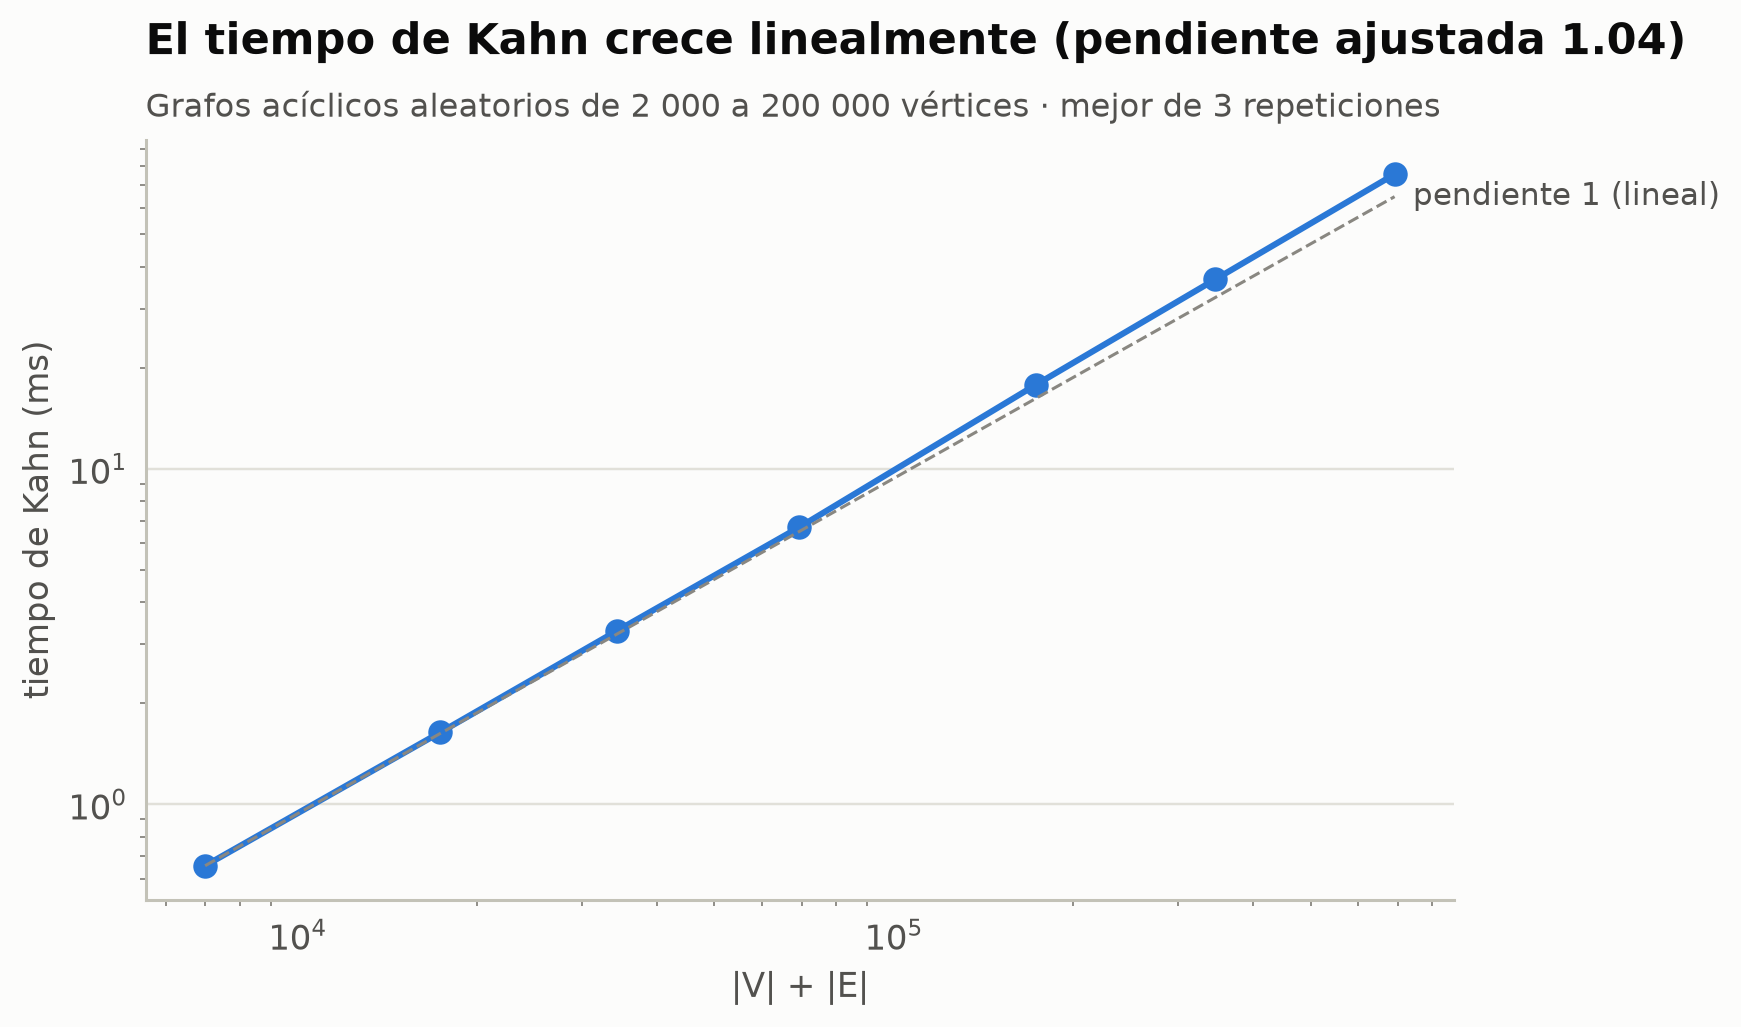

In [10]:
rng = np.random.default_rng(181)
sizes, times = [], []
for n in [2_000, 5_000, 10_000, 20_000, 50_000, 100_000, 200_000]:
    succ = {i: [] for i in range(n)}
    for i in range(n - 1):
        k = rng.integers(1, 5)
        succ[i] = list(set(rng.integers(i + 1, min(n, i + 60), size=k).tolist()))
    m = sum(len(v) for v in succ.values())
    runs = []
    for _ in range(3):
        t0 = time.perf_counter()
        orden_topologico(succ)
        runs.append(time.perf_counter() - t0)
    best = min(runs)
    sizes.append(n + m)
    times.append(best)
sizes, times = np.array(sizes), np.array(times)
slope = np.polyfit(np.log10(sizes), np.log10(times), 1)[0]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.loglog(sizes, times * 1e3, "o-", color=ec.BLUE, lw=2)
ref = times[0] * 1e3 * sizes / sizes[0]
ax.loglog(sizes, ref, "--", color="#898781", lw=1)
ec.label_end(ax, sizes[-1], ref[-1], "pendiente 1 (lineal)")
ax.set_xlabel("|V| + |E|")
ax.set_ylabel("tiempo de Kahn (ms)")
ec.title(ax, f"El tiempo de Kahn crece linealmente (pendiente ajustada {slope:.2f})",
         "Grafos acíclicos aleatorios de 2 000 a 200 000 vértices · mejor de 3 repeticiones")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** En escala log-log los puntos siguen una recta de pendiente ≈ 1: duplicar $|V|+|E|$ duplica el
> tiempo. Ordenar un flujo de cien mil trabajos toma décimas de segundo; el cuello de botella de un gestor de flujos nunca
> es ordenar el grafo, sino **construirlo** (consultar el sistema de archivos) y **ejecutarlo**.

> ✅ **Compruebe su comprensión.** (1) Si reemplazamos la cola FIFO por una pila (LIFO), ¿el resultado sigue siendo un orden
> topológico? (2) ¿Puede un flujo tener dos órdenes topológicos distintos? ¿Qué implica eso para la reproducibilidad?
> *(Respuestas: (1) sí: la corrección sólo usa que un vértice entra en $Q$ cuando su grado llega a 0; (2) sí, y por eso un
> buen flujo no debe depender del orden en que se ejecuten trabajos independientes: cada trabajo escribe sólo sus propias
> salidas.)*

## 4. Dependencias por archivos: la herencia de Make

La idea de describir un cálculo como un grafo de **archivos** es mucho más antigua que la bioinformática. `make`, escrito en
los Laboratorios Bell a finales de los setenta (Feldman, 1979), nació para recompilar programas en C: un *makefile* declara,
para cada **objetivo**, de qué **prerrequisitos** depende y qué orden lo fabrica. `make` reconstruye el grafo, lo ordena y
ejecuta **sólo lo necesario**. Es la regla de la nevera: si la leche (prerrequisito) es más nueva que el yogur que hicimos con
ella (objetivo), el yogur está desactualizado y hay que rehacerlo.

**Definición (objetivo desactualizado).** Sea $\mathrm{pre}(t)$ el conjunto de prerrequisitos del objetivo $t$ y $\tau(f)$ la
fecha de última modificación del archivo $f$. El objetivo $t$ debe reconstruirse si y sólo si

$$
\mathrm{rehacer}(t) \;=\; \neg\,\mathrm{existe}(t)\;\lor\;\bigvee_{d\,\in\,\mathrm{pre}(t)}\Big[\mathrm{rehacer}(d)\;\lor\;\tau(d)>\tau(t)\Big]. \tag{18.3}
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{pre}(t)$ | archivos de los que depende $t$ (aristas entrantes en el grafo de archivos) |
| $\tau(f)$ | marca de tiempo de modificación (*mtime*) que guarda el sistema de archivos |
| $\neg,\ \lor$ | negación y disyunción lógicas |

La definición es **recursiva** y se evalúa en orden topológico: cuando llegamos a $t$ ya sabemos si cada prerrequisito se
rehace. Veámosla funcionar con un `make` de verdad (viene instalado en Colab y en casi cualquier Linux o macOS). El
*makefile* ordena la lista de genes con mutaciones del clon y cuenta cuántas caen en cada gen.

In [11]:
os.makedirs("make_demo", exist_ok=True)
with open("make_demo/genes.txt", "w") as fh:
    fh.write("\n".join(["topA", "pykF", "malT", "IS1", "fis", "IS1", "iclR", "IS1", "nadR"]) + "\n")
with open("make_demo/Makefile", "w") as fh:          # ¡las órdenes de make van con TABULADOR!
    fh.write("resumen.txt: ordenado.txt\n\tuniq -c ordenado.txt > resumen.txt\n\n"
             "ordenado.txt: genes.txt\n\tsort genes.txt > ordenado.txt\n")
print(open("make_demo/Makefile").read())

if shutil.which("make"):
    for step in ["primera vez", "otra vez, sin cambios", "tras modificar genes.txt"]:
        if step.startswith("tras"):
            time.sleep(1.1)                            # la resolución de mtime puede ser de 1 s
            with open("make_demo/genes.txt", "a") as fh:
                fh.write("mrdB\n")
        out, err, _ = sh("make", cwd="make_demo", quiet=True)
        print(f"── make ({step}):\n{(out + err).strip()}\n")
    print(open("make_demo/resumen.txt").read())
else:
    print("⚠️ make no está instalado en este sistema; la lógica es la de la función rehacer() de abajo.")

resumen.txt: ordenado.txt
	uniq -c ordenado.txt > resumen.txt

ordenado.txt: genes.txt
	sort genes.txt > ordenado.txt

── make (primera vez):
sort genes.txt > ordenado.txt
uniq -c ordenado.txt > resumen.txt

── make (otra vez, sin cambios):
make: `resumen.txt' is up to date.



── make (tras modificar genes.txt):
sort genes.txt > ordenado.txt
uniq -c ordenado.txt > resumen.txt

   3 IS1
   1 fis
   1 iclR
   1 malT
   1 mrdB
   1 nadR
   1 pykF
   1 topA



> 🔎 **Qué observamos.** La primera vez `make` ejecuta las dos órdenes en orden topológico (primero `sort`, después
> `uniq`). La segunda vez responde que `resumen.txt` está al día (*up to date*): no hace nada. Tras modificar `genes.txt`,
> su fecha es posterior a la de `ordenado.txt` y la ecuación (18.3) obliga a rehacer ambos objetivos.

Traslademos la ecuación (18.3) al grafo de trabajos del libro. Un cambio se propaga a **todos los descendientes** del trabajo
modificado, y a nadie más. Programemos `rehacer` literalmente (recursiva, con memoria) y preguntemos cuántos de los 18
trabajos reales (sin contar `all`) hay que repetir en cuatro escenarios.

> 🤔 **Antes de ejecutar, prediga.** Si cambian las lecturas de la muestra A, ¿cuántos trabajos se repiten? ¿Y si sólo
> cambiamos el umbral de `filtrar`? ¿Y si retocamos `multiqc`?

cambian las lecturas de A        → rehacer 11 de 18: fastp_A, mapear_A, dedup_A, llamar, filtrar, anotar, consenso_A, consenso_B, consenso_C, filogenia, multiqc
cambia el umbral de filtrar      → rehacer  6 de 18: filtrar, anotar, consenso_A, consenso_B, consenso_C, filogenia
cambia la referencia             → rehacer 14 de 18: bwa_index, mapear_A, mapear_B, mapear_C, dedup_A, dedup_B, dedup_C, llamar, filtrar, anotar, consenso_A, consenso_B, consenso_C, filogenia
cambia la plantilla del informe  → rehacer  1 de 18: multiqc


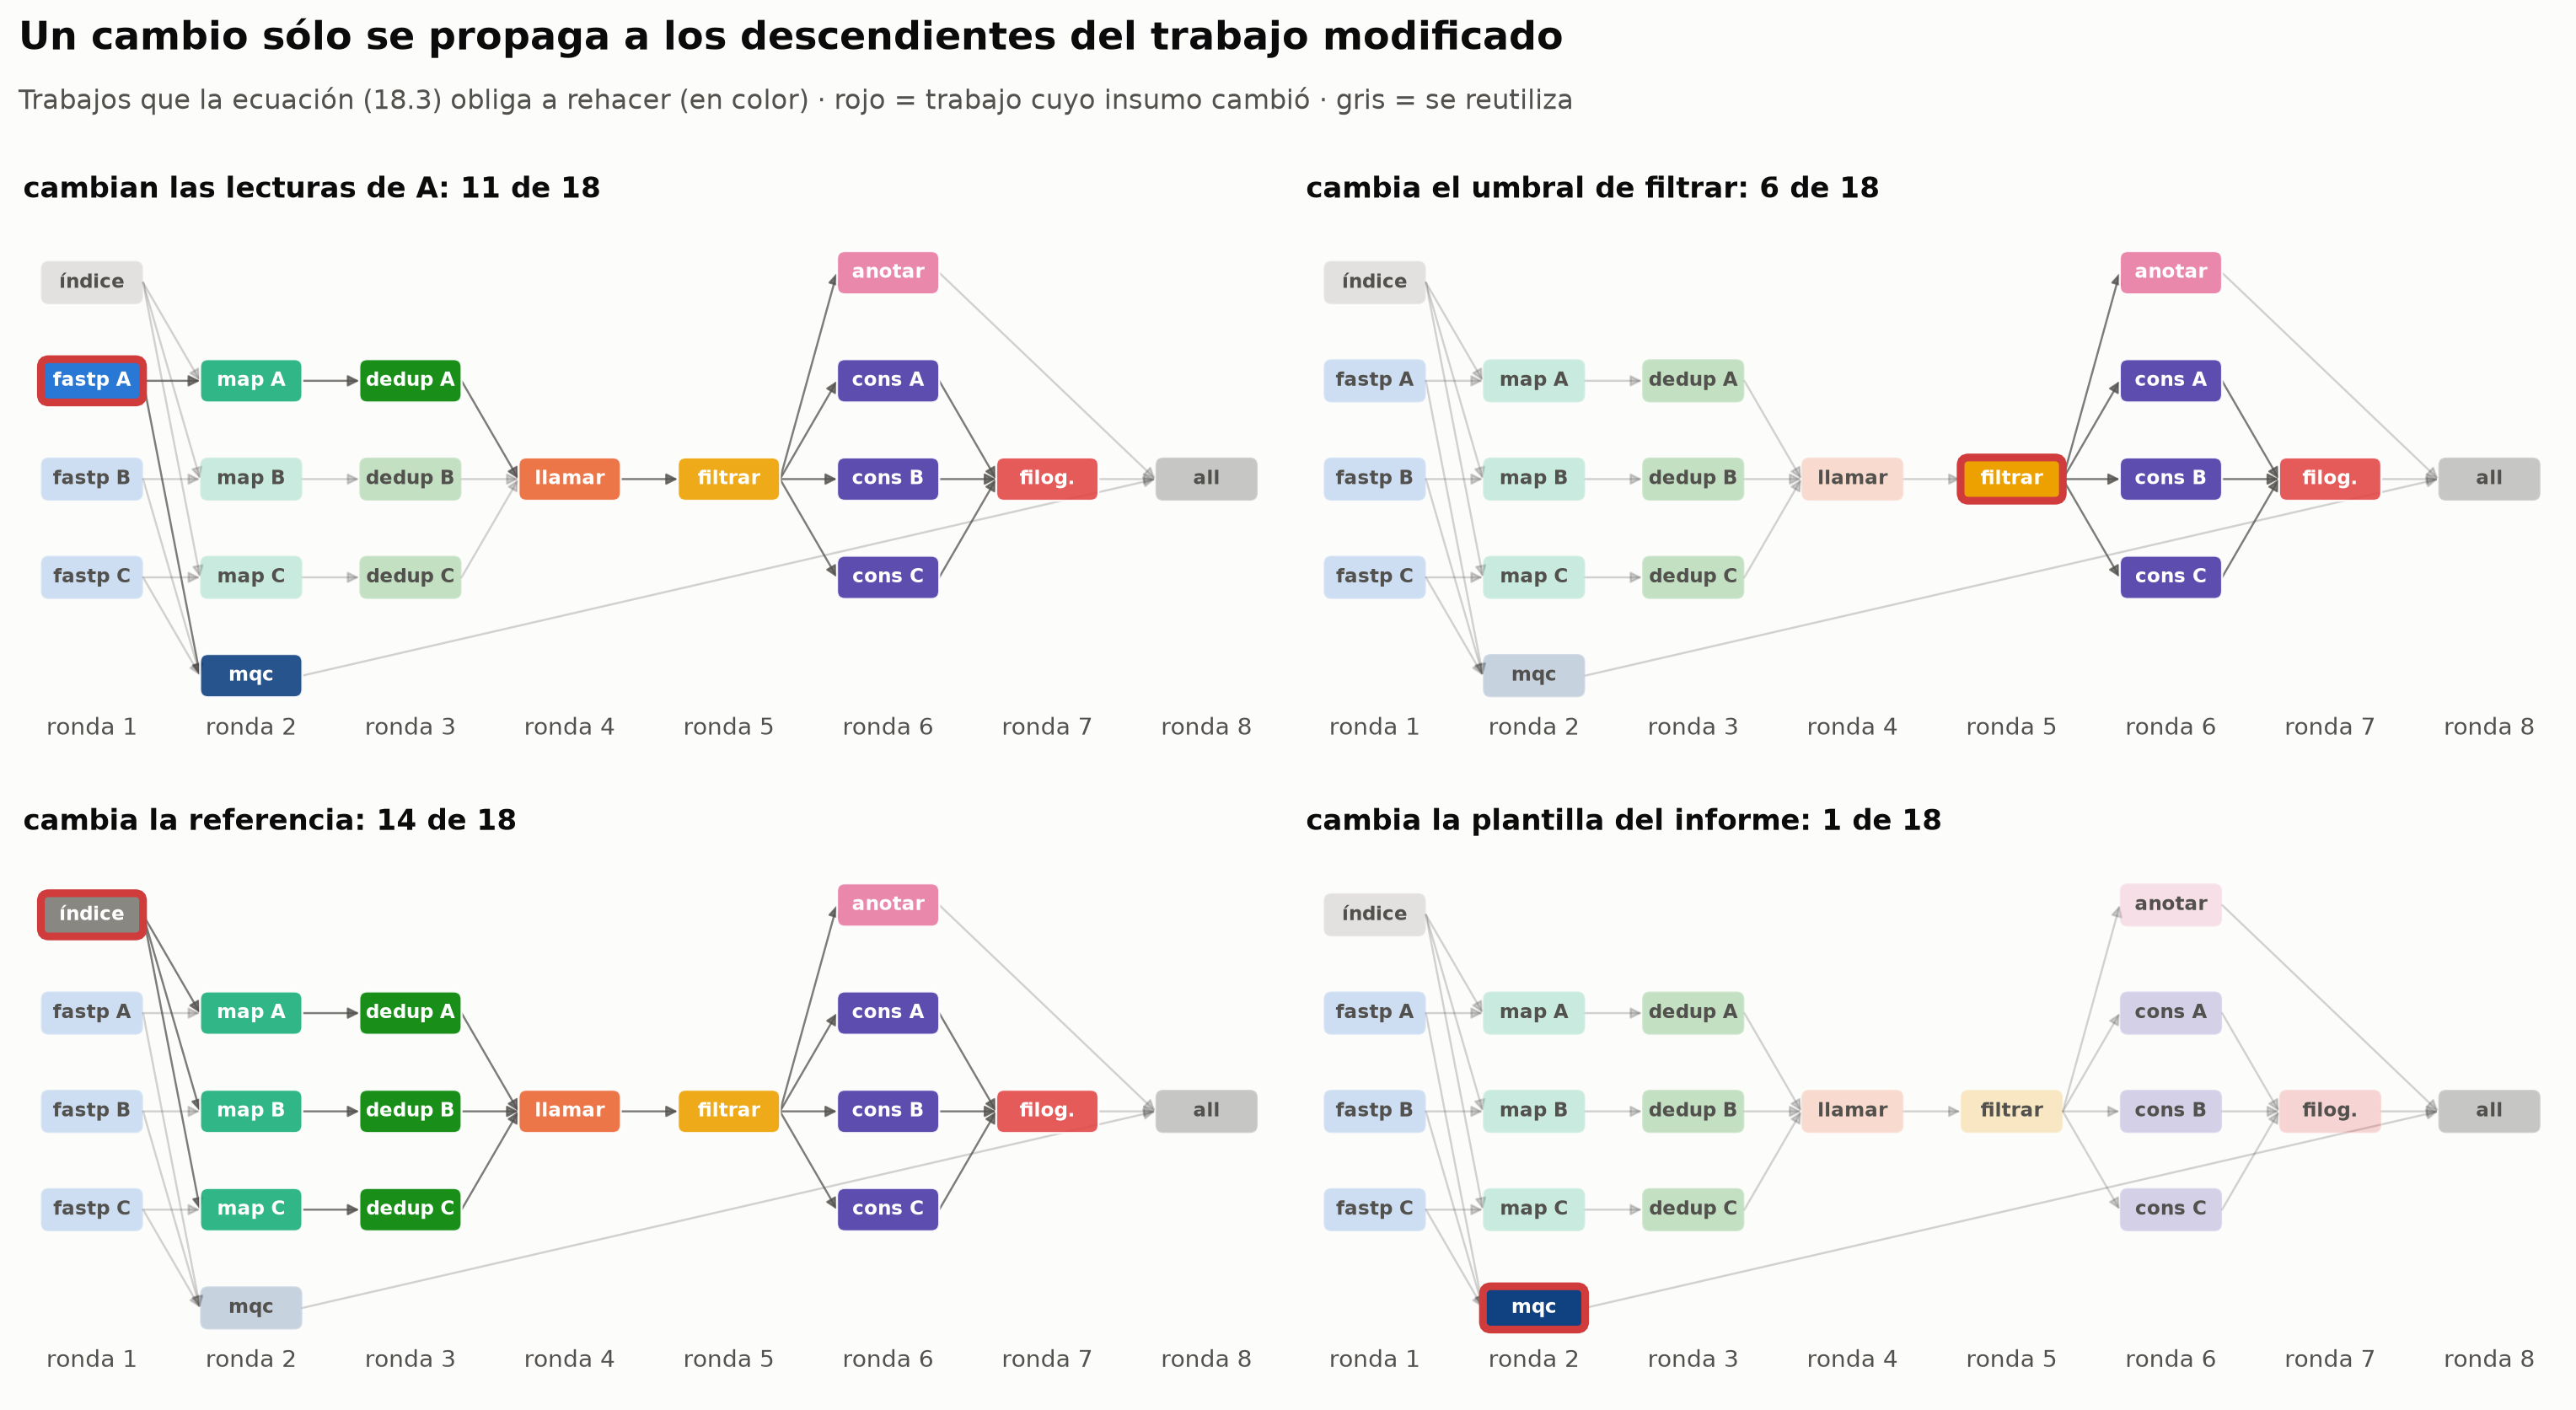

In [12]:
def jobs_to_redo(changed):
    """Evalúa la ecuación (18.3) sobre el grafo de trabajos: changed = trabajos cuya entrada o parámetros cambiaron."""
    memo = {}
    def redo(t):
        if t not in memo:
            memo[t] = (t in changed) or any(redo(d) for d in PRED[t])
        return memo[t]
    return {t for t in SUCC if t != "all" and redo(t)}

scenarios = {"fastp_A": "cambian las lecturas de A", "filtrar": "cambia el umbral de filtrar",
             "bwa_index": "cambia la referencia", "multiqc": "cambia la plantilla del informe"}
REDO = {}
for job, why in scenarios.items():
    REDO[job] = jobs_to_redo({job})
    assert REDO[job] == ({job} | descendants(SUCC, job)) - {"all"}   # = el trabajo y sus descendientes
    print(f"{why:32s} → rehacer {len(REDO[job]):2d} de 18: {', '.join(canonical(REDO[job]))}")

ABBR_RULE = {"bwa_index": "índice", "fastp": "fastp", "mapear": "map", "dedup": "dedup", "llamar": "llamar",
             "filtrar": "filtrar", "anotar": "anotar", "consenso": "cons", "filogenia": "filog.", "multiqc": "mqc", "all": "all"}
ABBR = {v: ABBR_RULE[rule_of(v)] + (" " + v.split("_")[-1] if v.split("_")[-1] in "ABC" else "") for v in SUCC}
fig, axes = plt.subplots(2, 2, figsize=(14, 7.2))
for ax, (job, why) in zip(axes.flat, scenarios.items()):
    others = set(SUCC) - REDO[job]
    draw_dag(ax, highlight={job: "#d03b3b"}, faded=others, labels=ABBR, fontsize=7.5)
    ax.set_title(f"{why}: {len(REDO[job])} de 18", loc="left", fontsize=11)
ec.fig_title(fig, "Un cambio sólo se propaga a los descendientes del trabajo modificado",
             "Trabajos que la ecuación (18.3) obliga a rehacer (en color) · rojo = trabajo cuyo insumo cambió · gris = se reutiliza")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Las cifras son las del libro: cambiar las lecturas de A obliga a rehacer **11** trabajos (su
> `fastp`, su mapeo y su `dedup`, el llamado conjunto y todo lo que cuelga de él, y `multiqc`); cambiar el umbral de
> `filtrar`, sólo **6**; cambiar la referencia, **14**; retocar `multiqc`, sólo **1**. Ésta es la *mise en place* del jefe
> de cocina: nunca se vuelven a tostar los huesos si sólo salió mal la salsa.

Las limitaciones de `make` (un único comodín `%` por regla, un lenguaje propio poco expresivo, ninguna noción de clúster ni
de entornos de software) motivaron la generación de gestores que estudiamos a continuación.

## 5. Snakemake: reglas, comodines e inferencia hacia atrás

Snakemake (Köster y Rahmann, 2012; Mölder *et al.*, 2021) conserva la filosofía de `make` (reglas que producen archivos a
partir de archivos) pero la escribe en una extensión de **Python**. Cada `rule` declara `input`, `output` y la orden que los
conecta (`shell`, `run` con Python o `script`), y puede añadir `threads`, `log`, `params`, `resources` o el entorno de
software (`conda`, `container`).

### Comodines

La pieza que hace escalar una regla es el **comodín** (*wildcard*): un nombre entre llaves dentro de un patrón de archivo,
como `mapeo/{m}.dedup.bam`. Con palabras simples: el patrón es un formulario con casillas en blanco; al ver el archivo
`mapeo/A.dedup.bam`, Snakemake rellena la casilla `m = A` y copia ese valor en los demás formularios de la regla.

Formalmente, un patrón $p$ con comodines $w_1,\dots,w_k$ define una expresión regular $\rho(p)$ en la que cada $\{w_i\}$ se
sustituye por un grupo con nombre (por defecto `.+`) y el resto se toma literalmente. Un archivo $f$ **coincide** con $p$ si
$\rho(p)$ reconoce $f$ completo, y la coincidencia **asigna** valores $\sigma=\{w_i\mapsto s_i\}$ que se sustituyen en los
patrones de entrada:

$$
f \in \mathcal{L}\big(\rho(p_{\text{sal}})\big) \;\Longrightarrow\; \text{entradas}(f) = \big\{\,\sigma(p) : p\in P_{\text{ent}}\,\big\}. \tag{18.4}
$$

| Símbolo | Significado |
|---|---|
| $p_{\text{sal}},\ P_{\text{ent}}$ | patrón de salida de la regla y conjunto de sus patrones de entrada |
| $\rho(p)$ | expresión regular asociada al patrón $p$ |
| $\mathcal{L}(\rho)$ | lenguaje reconocido por $\rho$: los nombres de archivo que coinciden |
| $\sigma$ | asignación de valores a los comodines obtenida de la coincidencia |

### Inferencia hacia atrás

Snakemake **no empieza por el principio sino por el final**. Parte de los archivos objetivo (las entradas de la primera
regla, `all`), busca la regla cuya salida coincide, calcula con $\sigma$ las entradas y repite recursivamente hasta llegar a
archivos que ya existen. El grafo **no está escrito en ninguna parte**: se deduce de los nombres de archivo. Es un modelo
**bajo demanda** (*pull*): sólo se construye lo que alguien pidió, igual que en una cocina sólo se prepara lo que aparece en
las comandas. El programa del libro (`inferir_dag.py`) reproduce la idea en unas líneas:

In [13]:
REGLAS = [  # (nombre, salidas, entradas)
    ("fastp", ["limpio/{m}_R1.fq.gz", "limpio/{m}_R2.fq.gz"],
              ["datos/{m}_R1.fastq.gz", "datos/{m}_R2.fastq.gz"]),
    ("mapear", ["mapeo/{m}.ordenado.bam"],
               ["limpio/{m}_R1.fq.gz", "limpio/{m}_R2.fq.gz"]),
    ("dedup", ["mapeo/{m}.dedup.bam"], ["mapeo/{m}.ordenado.bam"]),
]

def a_regex(patron):
    # 'mapeo/{m}.bam'  ->  'mapeo/(?P<m>.+)\.bam$'
    partes = re.split(r"\{(\w+)\}", patron)
    rx = "".join(re.escape(p) if i % 2 == 0 else f"(?P<{p}>.+)"
                 for i, p in enumerate(partes))
    return re.compile(rx + "$")

def inferir(objetivo, dag):
    for nombre, salidas, entradas in REGLAS:
        for s in salidas:
            hallado = a_regex(s).match(objetivo)
            if hallado:
                comodines = hallado.groupdict()
                ins = [e.format(**comodines) for e in entradas]
                dag[objetivo] = (nombre, comodines, ins)
                for f in ins:
                    if f not in dag:
                        inferir(f, dag)
                return
    dag[objetivo] = ("(archivo fuente)", {}, [])

print("ρ('mapeo/{m}.dedup.bam') =", a_regex("mapeo/{m}.dedup.bam").pattern, "\n")
dag = {}
inferir("mapeo/A.dedup.bam", dag)
for f, (regla, w, ins) in dag.items():
    print(f"{f:24s} <- {regla:16s} {w}")

ρ('mapeo/{m}.dedup.bam') = mapeo/(?P<m>.+)\.dedup\.bam$ 

mapeo/A.dedup.bam        <- dedup            {'m': 'A'}
mapeo/A.ordenado.bam     <- mapear           {'m': 'A'}
limpio/A_R1.fq.gz        <- fastp            {'m': 'A'}
datos/A_R1.fastq.gz      <- (archivo fuente) {}
datos/A_R2.fastq.gz      <- (archivo fuente) {}
limpio/A_R2.fq.gz        <- fastp            {'m': 'A'}


> 🔎 **Qué observamos.** La salida es idéntica a la consola del libro: partiendo de `mapeo/A.dedup.bam`, el programa
> descubre por sí solo que necesita `mapeo/A.ordenado.bam`, luego las lecturas limpias y por fin los FASTQ crudos. Nuestra
> versión de juguete no sabe que los dos archivos limpios de A salen de **un mismo** trabajo; Snakemake sí, porque agrupa las
> salidas de una regla con la misma $\sigma$. Tampoco resuelve ambigüedades: si dos reglas pueden producir el mismo archivo,
> Snakemake se detiene y pide `ruleorder` o `wildcard_constraints`.

> ✅ **Compruebe su comprensión.** ¿Qué asignación $\sigma$ produce el patrón `limpio/{m}_R1.fq.gz` para el archivo
> `limpio/REL7179B_R1.fq.gz`? ¿Y para `limpio/A_R1_R1.fq.gz`? *(Respuesta: `m = REL7179B`; y `m = A_R1`, porque `.+` es
> voraz: por eso conviene restringir los comodines con `wildcard_constraints`, como `m="[A-Za-z0-9-]+"`.)*

### Un *Snakefile* real con el clon del LTEE

Pasemos de la teoría a un flujo que **se ejecuta de verdad** en este notebook. Usaremos las lecturas del clon REL7179B que ya
conocemos (SRR2584863; las ventanas alrededor de sus variantes, Lección 9.2) y el genoma del ancestro REL606. Para tener
**tres muestras** como en el libro, repartimos los pares de lecturas en tres submuestras A, B y C, como si fueran tres
carriles (*lanes*) del secuenciador. Las reglas `mapear`, `dedup`, `llamar`, `filtrar` y `consenso` son **exactamente** las
del libro (BWA-MEM, `samtools`, `bcftools`); tres reglas usan Python puro para no depender de más programas: `qc` hace el
papel de `fastp` (descarta pares con calidad media < 20), `anotar` el de SnpEff (cruza cada SNV con los genes de REL606) y
`distancias` el de la filogenia (cuenta diferencias entre secuencias consenso). El grafo resultante tiene **la misma forma**
que el del libro: 19 trabajos.

Primero, las herramientas. En Colab se instalan `snakemake` (con `pip`) y `bwa`, `samtools` y `bcftools` (con `apt-get`);
Graphviz (`dot`) ya viene instalado.

In [14]:
if not shutil.which("snakemake"):
    %pip install -q snakemake
if IN_COLAB and not all(shutil.which(t) for t in ("bwa", "samtools", "bcftools")):
    !apt-get -qq update > /dev/null
    !apt-get -qq install -y bwa samtools bcftools > /dev/null
if IN_COLAB and not shutil.which("dot"):
    !apt-get -qq install -y graphviz > /dev/null

def first_line(cmd):
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    txt = (p.stdout + p.stderr).strip().splitlines()
    return next((l.strip() for l in txt if re.search(r"\d+\.\d+", l)), "no encontrado")

VERSIONS = {"snakemake": first_line("snakemake --version"),
            "bwa": first_line("bwa 2>&1 | grep -i version"),
            "samtools": first_line("samtools --version | head -1"),
            "bcftools": first_line("bcftools --version | head -1"),
            "graphviz": first_line("dot -V")}
for k, v in VERSIONS.items():
    print(f"{k:9s} {v}")
HAS_TOOLS = all(shutil.which(t) for t in ("snakemake", "bwa", "samtools", "bcftools"))
assert HAS_TOOLS, "Faltan herramientas: en Colab ejecute de nuevo esta celda; fuera de Colab: conda install -c bioconda snakemake bwa samtools bcftools"

snakemake 9.27.0
bwa       Version: 0.7.19-r1273
samtools  samtools 1.24
bcftools  bcftools 1.24
graphviz  dot - graphviz version 14.1.2 (0)


Ahora los datos, organizados como en un proyecto real: `datos/` (crudos, que **nunca** se modifican a mano), `ref/`
(referencia y anotación) y `config/`. El reparto en tres submuestras es determinista (el par $i$ va a la muestra
$i \bmod 3$), de modo que todos obtenemos los mismos archivos.

In [15]:
W = "flujo181"                                   # directorio del proyecto
for d in ("datos", "ref", "config", "envs"):
    os.makedirs(f"{W}/{d}", exist_ok=True)
with gzip.open(course_file("NC_012967.1.fasta.gz"), "rt") as fh, open(f"{W}/ref/REL606.fa", "w") as out:
    out.write(fh.read())
shutil.copy(course_file("NC_012967.1_features.tsv.gz"), f"{W}/ref/genes.tsv.gz")

readers = [gzip.open(course_file(f"SRR2584863_variant_windows_{r}.fastq.gz"), "rt") for r in (1, 2)]
writers = {(m, r): gzip.open(f"{W}/datos/{m}_R{r}.fastq.gz", "wt", compresslevel=1) for m in "ABC" for r in (1, 2)}
i = 0
while True:
    recs = [[fh.readline() for _ in range(4)] for fh in readers]
    if not recs[0][0]:
        break
    for r in (1, 2):
        writers["ABC"[i % 3], r].writelines(recs[r - 1])
    i += 1
for fh in list(writers.values()) + readers:
    fh.close()
print(f"{i:,} pares de lecturas repartidos en 3 muestras (~{i // 3:,} pares cada una)")
for f in sorted(os.listdir(f"{W}/datos")):
    print(f"  datos/{f:18s} {os.path.getsize(f'{W}/datos/{f}') / 1e3:6.0f} kB")

17,910 pares de lecturas repartidos en 3 muestras (~5,970 pares cada una)
  datos/A_R1.fastq.gz         846 kB
  datos/A_R2.fastq.gz         874 kB
  datos/B_R1.fastq.gz         847 kB
  datos/B_R2.fastq.gz         877 kB
  datos/C_R1.fastq.gz         846 kB
  datos/C_R2.fastq.gz         874 kB


El archivo de configuración separa **lo que cambia entre proyectos** (muestras, referencia, umbrales) de **la lógica**: el
mismo *Snakefile* sirve para 3 o para 300 aislados.

In [16]:
%%writefile flujo181/config/config.yaml
muestras: ["A", "B", "C"]
referencia: "ref/REL606.fa"
anotacion: "ref/genes.tsv.gz"
filtro: "QUAL>=30 && INFO/DP>=10"
calidad_minima: 20

Writing flujo181/config/config.yaml


Y el *Snakefile*. Léalo despacio y compárelo con el del libro: `configfile`, `wildcard_constraints`, la regla `all` al
principio (define el objetivo por defecto), `temp()` para intermedios que se borran solos, `multiext()` para las cinco
salidas de `bwa index`, `expand()` para las aristas "muchos a uno", `threads`, `log`, `params` con una función de los
comodines y bloques `run:` con Python.

In [17]:
%%writefile flujo181/Snakefile
# Mini-flujo del curso: lecturas del clon REL7179B del LTEE -> variantes anotadas
import gzip, json

configfile: "config/config.yaml"

MUESTRAS = config["muestras"]         # ["A", "B", "C"]
REF = config["referencia"]            # "ref/REL606.fa"

wildcard_constraints:
    m="[A-Za-z0-9-]+"


rule all:
    input:
        "resultados/anotado.tsv",
        "resultados/distancias.tsv",
        "resultados/informe_qc.tsv",


rule qc:                               # en el papel de fastp (Python puro)
    input:
        r1="datos/{m}_R1.fastq.gz",
        r2="datos/{m}_R2.fastq.gz",
    output:
        r1=temp("limpio/{m}_R1.fq.gz"),
        r2=temp("limpio/{m}_R2.fq.gz"),
        js="qc/{m}.json",
    params: qmin=config["calidad_minima"]
    run:
        def mean_q(q):
            return sum(ord(c) - 33 for c in q.strip()) / max(1, len(q.strip()))
        kept = total = 0
        with gzip.open(input.r1, "rt") as f1, gzip.open(input.r2, "rt") as f2, \
             gzip.open(output.r1, "wt", compresslevel=1) as o1, \
             gzip.open(output.r2, "wt", compresslevel=1) as o2:
            while True:
                a = [f1.readline() for _ in range(4)]
                b = [f2.readline() for _ in range(4)]
                if not a[0]:
                    break
                total += 1
                if min(mean_q(a[3]), mean_q(b[3])) >= params.qmin:
                    kept += 1
                    o1.writelines(a)
                    o2.writelines(b)
        with open(output.js, "w") as fh:
            json.dump({"muestra": wildcards.m, "pares": total, "conservados": kept}, fh)


rule bwa_index:
    input: REF
    output: multiext(REF, ".amb", ".ann", ".bwt", ".pac", ".sa", ".fai")
    log: "logs/bwa_index.log"
    shell: "bwa index {input} 2> {log} && samtools faidx {input}"


rule mapear:
    input:
        ref=REF,
        idx=rules.bwa_index.output,
        r1="limpio/{m}_R1.fq.gz",
        r2="limpio/{m}_R2.fq.gz",
    output: temp("mapeo/{m}.ordenado.bam")
    params: rg=lambda wc: f"@RG\\tID:{wc.m}\\tSM:{wc.m}"
    log: "logs/mapear/{m}.log"
    threads: 2
    shell:
        """
        bwa mem -t {threads} -R '{params.rg}' {input.ref} \
            {input.r1} {input.r2} > {output}.sam 2> {log}
        samtools fixmate -m {output}.sam {output}.fm.bam
        samtools sort -@ {threads} -o {output} {output}.fm.bam 2>> {log}
        rm {output}.sam {output}.fm.bam
        """


rule dedup:
    input: "mapeo/{m}.ordenado.bam"
    output:
        bam="mapeo/{m}.dedup.bam",
        bai="mapeo/{m}.dedup.bam.bai",
    shell:
        "samtools markdup {input} {output.bam} && "
        "samtools index {output.bam}"


rule llamar:
    input:
        ref=REF,
        idx=rules.bwa_index.output,
        bams=expand("mapeo/{m}.dedup.bam", m=MUESTRAS),
        bais=expand("mapeo/{m}.dedup.bam.bai", m=MUESTRAS),
    output: "variantes/crudo.bcf"
    log: "logs/llamar.log"
    shell:
        """
        bcftools mpileup -f {input.ref} -a AD,DP -Ob \
            -o {output}.pila {input.bams} 2> {log}
        bcftools call --ploidy 1 -mv -V indels -Ob \
            -o {output} {output}.pila 2>> {log}
        rm {output}.pila
        """


rule filtrar:
    input: "variantes/crudo.bcf"
    output:
        vcf="variantes/filtrado.vcf.gz",
        tbi="variantes/filtrado.vcf.gz.tbi",
    params: expr=config["filtro"]     # "QUAL>=30 && INFO/DP>=10"
    shell:
        "bcftools filter -i '{params.expr}' -Oz -o {output.vcf} "
        "{input} && bcftools index -t {output.vcf}"


rule anotar:                           # en el papel de SnpEff (Python puro)
    input:
        vcf="variantes/filtrado.vcf.gz",
        genes=config["anotacion"],
    output: "resultados/anotado.tsv"
    run:
        import csv
        with gzip.open(input.genes, "rt") as fh:
            cds = [r for r in csv.DictReader((l for l in fh if not l.startswith("#")), delimiter="\t")
                   if r["type"] == "CDS"]
        with gzip.open(input.vcf, "rt") as fh, open(output[0], "w") as out:
            out.write("POS\tREF\tALT\tQUAL\tgen\tproducto\n")
            for line in fh:
                if line.startswith("#"):
                    continue
                f = line.split("\t")
                pos = int(f[1])
                hit = [r for r in cds if int(r["start"]) <= pos <= int(r["end"])]
                gene = ";".join(r["gene"] or r["locus_tag"] for r in hit) or "intergénica"
                prod = ";".join(r["product"] for r in hit) or "—"
                out.write(f"{pos}\t{f[3]}\t{f[4]}\t{float(f[5]):.1f}\t{gene}\t{prod}\n")


rule consenso:
    input:
        ref=REF,
        vcf="variantes/filtrado.vcf.gz",
        tbi="variantes/filtrado.vcf.gz.tbi",
    output: "consenso/{m}.fa"
    log: "logs/consenso/{m}.log"
    shell:
        """
        bcftools consensus -f {input.ref} -s {wildcards.m} \
            -o {output}.tmp {input.vcf} 2> {log}
        sed 's/^>.*/>{wildcards.m}/' {output}.tmp > {output}
        rm {output}.tmp
        """


rule distancias:                       # en el papel de la filogenia (IQ-TREE)
    input:
        ref=REF,
        fas=expand("consenso/{m}.fa", m=MUESTRAS),
    output: "resultados/distancias.tsv"
    run:
        def read_fasta(path):
            return "".join(l.strip() for l in open(path) if not l.startswith(">")).upper()
        seqs = {"REL606": read_fasta(input.ref)}
        seqs.update({m: read_fasta(p) for m, p in zip(MUESTRAS, input.fas)})
        names = list(seqs)
        d = {(a, b): 0 for a in names for b in names}
        for i, a in enumerate(names):          # número de posiciones distintas (SNV)
            for b in names[i + 1:]:
                d[a, b] = d[b, a] = sum(map(str.__ne__, seqs[a], seqs[b]))
        with open(output[0], "w") as out:
            out.write("\t" + "\t".join(names) + "\n")
            for a in names:
                out.write(a + "\t" + "\t".join(str(d[a, b]) for b in names) + "\n")


rule informe:                          # en el papel de MultiQC
    input: expand("qc/{m}.json", m=MUESTRAS)
    output: "resultados/informe_qc.tsv"
    run:
        with open(output[0], "w") as out:
            out.write("muestra\tpares\tconservados\n")
            for p in input:
                r = json.load(open(p))
                out.write(f"{r['muestra']}\t{r['pares']}\t{r['conservados']}\n")

Writing flujo181/Snakefile


Antes de ejecutar nada, el **ensayo en seco** (`snakemake -n`): Snakemake infiere el grafo hacia atrás desde `all` y nos
dice qué trabajos ejecutaría y por qué. Es el primer comando que conviene lanzar siempre.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántos trabajos anunciará el ensayo en seco? ¿Cuántos de la regla `mapear`?

In [18]:
def smk(args, quiet=False):
    """Ejecuta snakemake dentro del proyecto y devuelve todo lo que escribió (stdout + stderr) y los segundos."""
    out, err, secs = sh(f"snakemake {args}", cwd=W, quiet=quiet)
    return out + err, secs

def job_stats(log):
    """Extrae la tabla 'Job stats' del registro de Snakemake: {regla: número de trabajos}."""
    m = re.search(r"Job stats:\n.*?\n-+\s+-+\n(.*?)\ntotal\s+(\d+)", log, re.S)
    if not m:
        return {}
    return {a: int(b) for a, b in (l.split() for l in m.group(1).strip().splitlines())}

log, secs = smk("-n --cores 3")
stats = job_stats(log)
print(f"ensayo en seco: {sum(stats.values())} trabajos en {secs:.1f} s")
display(pd.Series(stats, name="trabajos").to_frame().T)
print("\n".join(l for l in log.splitlines() if l.startswith("    output files have") or l.startswith("        ")))

$ snakemake -n --cores 3


ensayo en seco: 19 trabajos en 0.7 s


,bwa_index,qc,informe,mapear,dedup,llamar,filtrar,anotar,consenso,distancias,all
trabajos,1,3,1,3,3,1,1,1,3,1,1


        all, anotar, consenso, dedup, distancias, filtrar, informe, llamar, mapear
    output files have to be generated:
        anotar, bwa_index, consenso, dedup, distancias, filtrar, informe, llamar, mapear, qc


> 🔎 **Qué observamos.** 19 trabajos: 3 de cada regla por muestra (`qc`, `mapear`, `dedup`, `consenso`) y uno de cada regla
> conjunta, más `all`, igual que en el grafo del libro. El motivo de todos es *output files have to be generated*: todavía no
> existe ningún resultado. Pidamos a Snakemake su grafo de trabajos (`--dag`, en el lenguaje de Graphviz) y dibujémoslo.

$ dot -Tpng -Gdpi=110 dag.dot -o dag.png


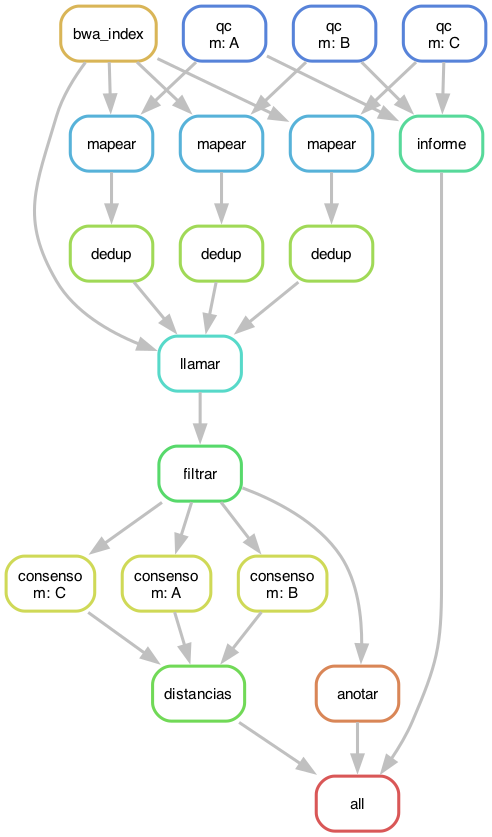

DAG de Snakemake: 19 trabajos, 27 aristas
anchos por ronda: [4, 4, 3, 1, 1, 4, 1, 1]
orden de Kahn: ['bwa_index', 'qc_A', 'qc_B', 'qc_C', 'mapear_A', 'mapear_B', 'mapear_C', 'informe', 'dedup_A', 'dedup_B', 'dedup_C', 'llamar', 'filtrar', 'anotar', 'consenso_A', 'consenso_B', 'consenso_C', 'distancias', 'all']


In [19]:
dot_src = sh("snakemake --dag", cwd=W, quiet=True)[0]     # stdout = sólo el texto del grafo (DOT)
dot_src = dot_src[dot_src.index("digraph"):]
with open(f"{W}/dag.dot", "w") as fh:
    fh.write(dot_src)
if shutil.which("dot"):
    sh("dot -Tpng -Gdpi=110 dag.dot -o dag.png", cwd=W)
    display(Image(f"{W}/dag.png", width=900))

# Convertimos el DOT en nuestro diccionario de sucesores para analizarlo con nuestro propio código.
# Graphviz sólo muestra el comodín de algunos trabajos: a los demás (mapear, dedup) les heredamos la muestra
# de su predecesor, recorriendo los identificadores en orden topológico (¡con nuestro Kahn!).
parsed = {}
for nid, lab in re.findall(r'^\s*(\d+)\[label = "([^"]+)"', dot_src, re.M):
    rule, _, wc = lab.partition("\\n")
    parsed[nid] = (rule, wc.split(": ")[1] if wc else "")
id_succ = {nid: [] for nid in parsed}
for a, b in re.findall(r"^\s*(\d+) -> (\d+)", dot_src, re.M):
    id_succ[a].append(b)
id_pred = predecessors(id_succ)
per_rule = collections.Counter(rule for rule, _ in parsed.values())
SAMPLES = ["A", "B", "C"]
name = {}
for nid in orden_topologico(id_succ):
    rule, wc = parsed[nid]
    if not wc and per_rule[rule] > 1:           # heredar la muestra de un predecesor
        wc = next(name[u].rsplit("_", 1)[1] for u in id_pred[nid] if name[u].rsplit("_", 1)[-1] in SAMPLES)
    name[nid] = f"{rule}_{wc}" if wc else rule
SMK = {name[a]: [name[b] for b in bs] for a, bs in id_succ.items()}
SMK_PRED = predecessors(SMK)
print(f"DAG de Snakemake: {len(SMK)} trabajos, {sum(map(len, SMK.values()))} aristas")
lev_smk = levels(SMK)
print("anchos por ronda:", [sum(1 for v in SMK if lev_smk[v] == k) for k in range(1, max(lev_smk.values()) + 1)])
print("orden de Kahn:", orden_topologico(SMK))

> 🔎 **Qué observamos.** El dibujo de Graphviz es el grafo que Snakemake **dedujo de los nombres de archivo**: nadie lo
> escribió. Tiene 19 trabajos y las mismas 8 rondas de anchos $4,4,3,1,1,4,1,1$ que el grafo del libro; hay una arista
> más (27 frente a 26), `bwa_index → llamar`, porque en nuestro *Snakefile* `llamar` también lee el índice de la
> referencia (`consenso` sólo lee la referencia, que no es un trabajo). Nuestro
> `orden_topologico` de la sección 3 lo ordena sin problemas: es el mismo algoritmo que usa el gestor.

Ahora sí, ejecutamos el flujo con 3 núcleos. Snakemake lanza en paralelo todo lo que está listo, respetando los `threads`
declarados de cada regla.

In [20]:
log, secs_full = smk("--cores 3")
steps = re.findall(r"(\d+) of (\d+) steps \((\d+%)\) done", log)
print(f"flujo completo en {secs_full:.1f} s · último contador: {' of '.join(steps[-1][:2])} steps ({steps[-1][2]}) done")
for f in sorted(os.listdir(f"{W}/mapeo")):
    print("  mapeo/" + f)
print("¿quedan intermedios temp()?", os.path.exists(f"{W}/limpio/A_R1.fq.gz"), os.path.exists(f"{W}/mapeo/A.ordenado.bam"))

$ snakemake --cores 3


flujo completo en 9.4 s · último contador: 19 of 19 steps (100%) done
  mapeo/A.dedup.bam
  mapeo/A.dedup.bam.bai
  mapeo/B.dedup.bam
  mapeo/B.dedup.bam.bai
  mapeo/C.dedup.bam
  mapeo/C.dedup.bam.bai
¿quedan intermedios temp()? False False


> 🔎 **Qué observamos.** El flujo completo tarda unos segundos (las lecturas son pocas). Los contadores `n of 19 steps done`
> muestran el avance. Los archivos marcados con `temp()` (lecturas limpias y BAM sin duplicados marcados) **ya no existen**:
> Snakemake los borró en cuanto ningún trabajo pendiente los necesitaba, ahorrando disco sin perder la reanudación.

Veamos los resultados: el informe de calidad, las variantes anotadas y las distancias entre secuencias consenso.

In [21]:
qc = pd.read_csv(f"{W}/resultados/informe_qc.tsv", sep="\t")
qc["% conservado"] = (100 * qc.conservados / qc.pares).round(1)
display(qc)
ann = pd.read_csv(f"{W}/resultados/anotado.tsv", sep="\t")
ann["producto"] = ann["producto"].str.slice(0, 55)
print(f"{len(ann)} SNV que pasan el filtro QUAL>=30 && INFO/DP>=10")
display(ann)
dist = pd.read_csv(f"{W}/resultados/distancias.tsv", sep="\t", index_col=0)
display(dist)

,muestra,pares,conservados,% conservado
0,A,5970,5085,85.2
1,B,5970,5103,85.5
2,C,5970,5101,85.4


20 SNV que pasan el filtro QUAL>=30 && INFO/DP>=10


,POS,REF,ALT,QUAL,gen,producto
0,9972,T,G,737.2,satP,acetate uptake transporter
1,263235,G,T,616.1,ECB_RS01240,IS1-like element IS1A family transposase
2,281923,G,T,737.2,intergénica,—
3,377000,T,G,712.1,ECB_RS01790,IS1-like element IS1A family transposase
4,648692,C,T,737.2,mrdB,peptidoglycan glycosyltransferase MrdB
5,1331794,C,A,737.2,topA,type I DNA topoisomerase
6,1733343,G,A,737.2,pykF,pyruvate kinase PykF
7,2407766,A,C,543.0,ECB_RS23940,IS1-like element IS1A family transposase
8,2446984,A,C,737.2,ECB_RS26305,protein YpeD
9,2618472,G,T,682.1,ECB_RS12910,IS1-like element IS1A family transposase


,REL606,A,B,C
REL606,0,20,20,20
A,20,0,0,0
B,20,0,0,0
C,20,0,0,0


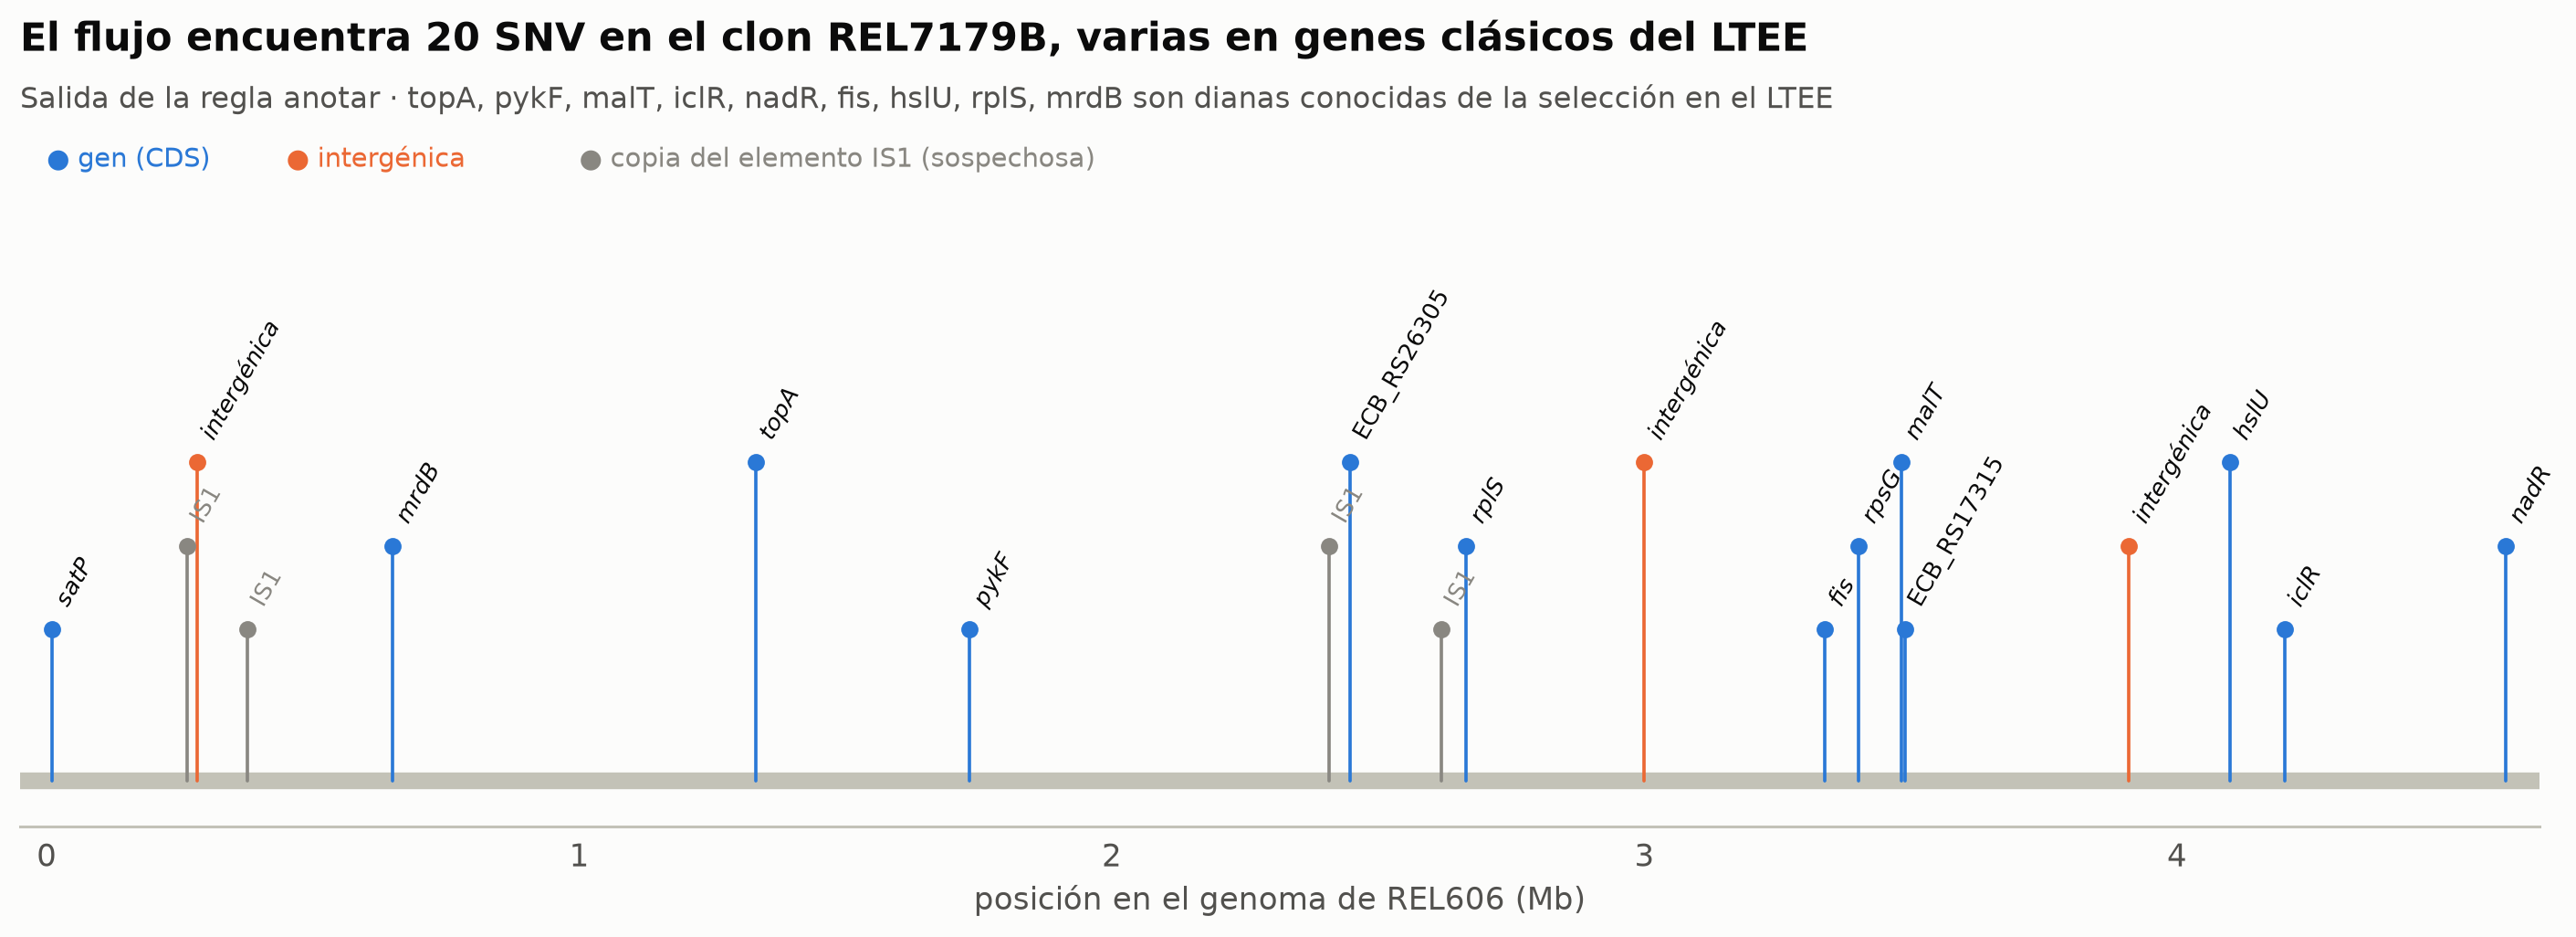

In [22]:
genome_len = sum(len(l.strip()) for l in open(f"{W}/ref/REL606.fa") if not l.startswith(">"))
is_is1 = ann["producto"].str.contains("IS1")
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axhline(0, color="#c3c2b7", lw=6, solid_capstyle="round", zorder=1)
for k, (_, r) in enumerate(ann.sort_values("POS").iterrows()):
    h = 1 + (k % 3) * 0.55
    col = ec.MUTED if is_is1.loc[r.name] else (ec.ORANGE if r["gen"] == "intergénica" else ec.BLUE)
    ax.plot([r.POS / 1e6] * 2, [0, h], color=col, lw=1.2, zorder=2)
    ax.scatter(r.POS / 1e6, h, s=38, color=col, zorder=3)
    ax.text(r.POS / 1e6, h + 0.12, r["gen"] if not is_is1.loc[r.name] else "IS1", rotation=60, fontsize=8.5,
            ha="left", va="bottom", color="#0b0b0b" if not is_is1.loc[r.name] else ec.MUTED,
            style="italic" if r["gen"][:3] != "ECB" else "normal")
ax.set_xlim(-0.05, genome_len / 1e6 + 0.05)
ax.set_ylim(-0.3, 4.3)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("posición en el genoma de REL606 (Mb)")
ax.text(0.0, 4.05, "● gen (CDS)", color=ec.BLUE, fontsize=9.5)
ax.text(0.45, 4.05, "● intergénica", color=ec.ORANGE, fontsize=9.5)
ax.text(1.0, 4.05, "● copia del elemento IS1 (sospechosa)", color=ec.MUTED, fontsize=9.5)
ec.title(ax, f"El flujo encuentra {len(ann)} SNV en el clon REL7179B, varias en genes clásicos del LTEE",
         "Salida de la regla anotar · topA, pykF, malT, iclR, nadR, fis, hslU, rplS, mrdB son dianas conocidas de la selección en el LTEE")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** El flujo reproduce el resultado de la Lección 9.2 sin que hayamos escrito el orden de un solo
> paso: SNV en genes que el LTEE ha hecho famosos (`topA`, `pykF`, `malT`, `iclR`, `nadR`, `fis`, `hslU`, `mrdB`…) y
> algunas en copias del elemento de inserción IS1, que ya sabemos que merecen desconfianza por ser repeticiones. Las tres
> submuestras dan **consensos idénticos** (distancia 0 entre A, B y C) y cada una difiere de REL606 en las mismas SNV:
> una prueba de consistencia gratuita, porque las tres provienen del mismo clon.

### La *mise en place* en acción: re-ejecución incremental

Ahora la parte más valiosa de un gestor: **no repetir lo que ya está hecho**. Probaremos cuatro cosas:

1. Volver a lanzar el flujo sin cambios.
2. `touch` sobre las lecturas de A (cambia la fecha, **no** el contenido).
3. Cambiar de verdad el contenido de las lecturas de A (el centro de secuenciación nos envía una versión corregida sin los
   últimos 30 pares).
4. Forzar que se rehaga `filtrar` (`-R filtrar`), como si hubiéramos cambiado su umbral.

> 🤔 **Antes de ejecutar, prediga.** Con la ecuación (18.3), ¿cuántos trabajos reales debería rehacer Snakemake en el caso 3?
> ¿Y en el caso 4? ¿Y qué hará en el caso 2?

In [23]:
def plan(args=""):
    log, secs = smk(f"-n --cores 3 {args}", quiet=True)
    st = job_stats(log)
    st.pop("all", None)
    return st, log

# 1. sin cambios
st, log = plan()
print("1. sin cambios        →", sum(st.values()), "trabajos ·", "Nothing to be done" in log and "«Nothing to be done»")

# 2. touch: cambia la fecha, no el contenido
time.sleep(1.1)
os.utime(f"{W}/datos/A_R1.fastq.gz")
st, log = plan()
print("2. touch A_R1         →", sum(st.values()), "trabajos")

# 3. contenido nuevo: quitamos los últimos 30 pares de la muestra A
for r in (1, 2):
    path = f"{W}/datos/A_R{r}.fastq.gz"
    lines = gzip.open(path, "rt").read().splitlines(True)
    with gzip.open(path, "wt", compresslevel=1) as fh:
        fh.writelines(lines[:-4 * 30])
st3, log3 = plan()
print("3. contenido nuevo A  →", sum(st3.values()), "trabajos:", st3)
reason = [l.strip() for l in log3.splitlines() if "reason:" in l][:2]
print("   motivos (primeros):", *reason, sep="\n     ")

# comparación con nuestra predicción sobre el DAG de Snakemake
pred3 = {"qc_A"} | descendants(SMK, "qc_A")
pred3.discard("all")
print(f"   predicción con la ecuación (18.3) sobre el DAG: {len(pred3)} trabajos → {', '.join(sorted(pred3))}")

1. sin cambios        → 0 trabajos · «Nothing to be done»


2. touch A_R1         → 0 trabajos


3. contenido nuevo A  → 11 trabajos: {'qc': 1, 'informe': 1, 'mapear': 1, 'dedup': 1, 'llamar': 1, 'filtrar': 1, 'anotar': 1, 'consenso': 3, 'distancias': 1}
   motivos (primeros):
     reason: Missing output files: limpio/A_R2.fq.gz, limpio/A_R1.fq.gz; Updated input files: datos/A_R2.fastq.gz, datos/A_R1.fastq.gz
     reason: Missing output files: mapeo/A.ordenado.bam; Input files updated by another job: limpio/A_R2.fq.gz, limpio/A_R1.fq.gz
   predicción con la ecuación (18.3) sobre el DAG: 11 trabajos → anotar, consenso_A, consenso_B, consenso_C, dedup_A, distancias, filtrar, informe, llamar, mapear_A, qc_A


> 🔎 **Qué observamos.** Sin cambios: nada que hacer. El caso 2 sorprende: **cero** trabajos, aunque la fecha de `A_R1`
> es ahora posterior a la de sus salidas y la ecuación (18.3) pura de `make` exigiría rehacer. La razón es que Snakemake
> moderno guarda en `.snakemake/` una **suma de verificación** (*checksum*) de cada entrada de hasta 1 MB y, si la fecha
> cambió pero el contenido no, no repite nada: es la idea de la sección 8 (claves de caché con *hash*). En el caso 3 el
> contenido sí cambió y Snakemake planea exactamente los **11** trabajos que predice nuestro análisis del grafo (la misma
> cifra del libro): `qc`, `mapear` y `dedup` de A, el llamado conjunto, `filtrar`, `anotar`, los tres `consenso`,
> `distancias` e `informe`. Ejecutémoslo de verdad y midamos el caso 4.

In [24]:
log, secs_inc = smk("--cores 3", quiet=True)
print(f"re-ejecución incremental (caso 3): {secs_inc:.1f} s frente a {secs_full:.1f} s del flujo completo")
st4, _ = plan("-R filtrar")
print("4. -R filtrar         →", sum(st4.values()), "trabajos:", st4)
new_qc = pd.read_csv(f"{W}/resultados/informe_qc.tsv", sep="\t")
print("\npares de A tras la corrección:", int(new_qc.loc[new_qc.muestra == "A", "pares"].iloc[0]),
      "· SNV tras rehacer:", len(pd.read_csv(f"{W}/resultados/anotado.tsv", sep="\t")))

re-ejecución incremental (caso 3): 7.4 s frente a 9.4 s del flujo completo


4. -R filtrar         → 6 trabajos: {'filtrar': 1, 'anotar': 1, 'consenso': 3, 'distancias': 1}

pares de A tras la corrección: 5940 · SNV tras rehacer: 20


> 🔎 **Qué observamos.** Con `-R filtrar` Snakemake rehace `filtrar` y sus descendientes: **6** trabajos (`filtrar`,
> `anotar`, tres `consenso` y `distancias`), de nuevo la cifra del libro. La muestra A ahora tiene 30 pares menos y la lista
> de variantes se actualizó sola. En un proyecto de 24 genomas bacterianos, donde el mapeo cuesta minutos por muestra, esta
> contabilidad ahorra horas.

Otras órdenes útiles de la consola del libro (no las ejecutamos todas aquí):

```bash
snakemake -n                       # ensayo en seco: qué trabajos y por qué
snakemake --dag | dot -Tpdf > dag.pdf
snakemake --cores 16 --sdm conda   # un entorno conda por regla (Snakemake ≥ 8)
snakemake --cores 16 -R filtrar    # rehace filtrar y descendientes
snakemake --report informe.html    # informe HTML con procedencia
```

> ⚠️ **Versiones de Snakemake.** La interfaz cambió en la versión 8: la antigua `--use-conda` es ahora
> `--software-deployment-method conda` (`--sdm conda`) y el envío a clústeres pasó a complementos de ejecución
> (`--executor slurm`). Consulte `snakemake --help` de **su** versión y anótela en el `README`.

## 6. Nextflow: procesos, canales y flujo de datos

Nextflow (Di Tommaso *et al.*, 2017) parte de otro modelo: el **flujo de datos** (*dataflow*). En lugar de reglas que
producen archivos con nombre hay **procesos** aislados que se comunican por **canales**, colas asíncronas por las que circulan
valores (rutas, cadenas, tuplas). Piense en una cadena de montaje con cintas transportadoras: cada estación trabaja en cuanto
le llega una pieza por cada una de sus cintas de entrada, y deja el resultado en su cinta de salida. No hay que reconstruir
nada hacia atrás: el grafo se desenvuelve **hacia adelante** a medida que llegan los datos. Es un modelo **por empuje**
(*push*).

**Definición (canales de cola y de valor).** Un **canal de cola** es una secuencia finita de elementos que se consumen: cada
elemento lo lee un único disparo del proceso. Un **canal de valor** contiene un solo elemento que puede leerse un número
ilimitado de veces. Si un proceso tiene canales de entrada de cola $c_1,\dots,c_k$ (y quizá otros de valor), el número de
tareas que ejecuta es

$$
n_{\text{tareas}} = \min_{1\le i\le k} |c_i|, \tag{18.5}
$$

y vale 1 si todas sus entradas son canales de valor.

| Símbolo | Significado |
|---|---|
| $c_i$ | $i$-ésimo canal de entrada **de cola** del proceso |
| $\lvert c_i\rvert$ | número de elementos que llegan por ese canal |
| $n_{\text{tareas}}$ | número de veces que se ejecuta el proceso |

La ecuación (18.5) explica el error más frecuente de quien empieza. Si el índice de BWA saliera por un canal de **cola** con
un elemento y las lecturas por otro con tres, el mapeo se ejecutaría $\min(1,3)=1$ vez: **sólo se mapearía la primera
muestra, sin ningún mensaje de error**. Simulémoslo en Python.

In [25]:
class Value:
    """Canal de valor: un único elemento que se relee sin agotarse."""
    def __init__(self, x):
        self.x = x

def run_process(name, *channels):
    """Dispara el proceso mientras haya un elemento en CADA canal de cola (los de valor se releen)."""
    queues = [list(c) for c in channels if not isinstance(c, Value)]
    n = min(len(q) for q in queues) if queues else 1          # ecuación (18.5)
    tasks = []
    for i in range(n):
        it = iter([q[i] for q in queues])
        tasks.append([c.x if isinstance(c, Value) else next(it) for c in channels])
    print(f"{name}: {len(tasks)} tarea(s) → {[t[0] for t in tasks]}")
    return tasks

reads = [("A", "A_R{1,2}.fastq.gz"), ("B", "B_R{1,2}.fastq.gz"), ("C", "C_R{1,2}.fastq.gz")]
print("❌ índice como canal de COLA:")
run_process("MAPEAR", reads, ["REL606.fa.*"])
print("✅ índice como canal de VALOR:")
run_process("MAPEAR", reads, Value("REL606.fa.*"))
print("✅ collect(): la cola de BAM se convierte en un único valor que dispara UNA vez el llamado conjunto:")
run_process("LLAMAR", Value(["A.dedup.bam", "B.dedup.bam", "C.dedup.bam"]), Value("REL606.fa"))

❌ índice como canal de COLA:
MAPEAR: 1 tarea(s) → [('A', 'A_R{1,2}.fastq.gz')]
✅ índice como canal de VALOR:
MAPEAR: 3 tarea(s) → [('A', 'A_R{1,2}.fastq.gz'), ('B', 'B_R{1,2}.fastq.gz'), ('C', 'C_R{1,2}.fastq.gz')]
✅ collect(): la cola de BAM se convierte en un único valor que dispara UNA vez el llamado conjunto:
LLAMAR: 1 tarea(s) → [['A.dedup.bam', 'B.dedup.bam', 'C.dedup.bam']]


[[['A.dedup.bam', 'B.dedup.bam', 'C.dedup.bam'], 'REL606.fa']]

> 🔎 **Qué observamos.** Con el índice como canal de cola, `MAPEAR` se dispara una sola vez (sólo la muestra A) y nadie se
> queja: el error es silencioso. Como canal de valor, se relee para cada muestra: tres tareas. En Nextflow un proceso cuyas
> entradas son todas de valor (como `BWA_INDEX(file(params.ref))`) produce canales de valor, y el operador `collect()`
> convierte una cola en un único valor (la lista completa), justo lo que necesita el llamado conjunto.

He aquí el equivalente en Nextflow (DSL2, una extensión de Groovy) del núcleo de nuestro *Snakefile*: índice, mapeo,
duplicados, llamado conjunto y filtro. Lo escribimos al disco; más abajo hay una celda **opcional** para ejecutarlo si su
entorno tiene Java ≥ 17.

In [26]:
%%writefile flujo181/main.nf
params.lecturas = "datos/*_R{1,2}.fastq.gz"
params.ref      = "ref/REL606.fa"
params.outdir   = "resultados_nf"

process BWA_INDEX {
    input:
    path fa
    output:
    tuple path(fa), path("${fa}.*")
    script:
    """
    bwa index ${fa}
    samtools faidx ${fa}
    """
}

process MAPEAR {
    tag "${id}"
    cpus 2
    input:
    tuple val(id), path(reads)
    tuple path(fa), path(idx)
    output:
    tuple val(id), path("${id}.ordenado.bam")
    script:
    """
    bwa mem -t ${task.cpus} -R '@RG\\tID:${id}\\tSM:${id}' ${fa} ${reads} > ${id}.sam
    samtools fixmate -m ${id}.sam ${id}.fm.bam
    samtools sort -@ ${task.cpus} -o ${id}.ordenado.bam ${id}.fm.bam
    """
}

process DEDUP {
    tag "${id}"
    input:
    tuple val(id), path(bam)
    output:
    tuple val(id), path("${id}.dedup.bam"), path("${id}.dedup.bam.bai")
    script:
    """
    samtools markdup ${bam} ${id}.dedup.bam
    samtools index ${id}.dedup.bam
    """
}

process LLAMAR {
    input:
    path bams
    tuple path(fa), path(idx)
    output:
    path "crudo.bcf"
    script:
    """
    bcftools mpileup -f ${fa} -a AD,DP -Ob -o pila.bcf *.dedup.bam
    bcftools call --ploidy 1 -mv -V indels -Ob -o crudo.bcf pila.bcf
    """
}

process FILTRAR {
    publishDir params.outdir, mode: 'copy'
    input:
    path bcf
    output:
    tuple path("filtrado.vcf.gz"), path("filtrado.vcf.gz.tbi")
    script:
    """
    bcftools filter -i 'QUAL>=30 && INFO/DP>=10' -Oz -o filtrado.vcf.gz ${bcf}
    bcftools index -t filtrado.vcf.gz
    """
}

workflow {
    lecturas = Channel.fromFilePairs(params.lecturas)      // cola: (id, [R1, R2]) por muestra
    BWA_INDEX(file(params.ref))                            // entradas de valor → salida de valor
    MAPEAR(lecturas, BWA_INDEX.out)
    DEDUP(MAPEAR.out)
    bams = DEDUP.out.map { id, bam, bai -> [bam, bai] }.collect()   // cola → un único valor
    LLAMAR(bams, BWA_INDEX.out)
    FILTRAR(LLAMAR.out)
}

Writing flujo181/main.nf


In [27]:
# Celda OPCIONAL: ejecuta main.nf con Nextflow (requiere Java ≥ 17; tarda ~1 min en instalarse en Colab)
RUN_NEXTFLOW = False          # cámbielo a True para probarlo

def java_major():
    p = subprocess.run("java -version", shell=True, capture_output=True, text=True)
    m = re.search(r'version "(\d+)', p.stderr + p.stdout)
    return int(m.group(1)) if (p.returncode == 0 and m) else 0

if RUN_NEXTFLOW:
    if IN_COLAB and java_major() < 17:
        !apt-get -qq install -y openjdk-17-jre-headless > /dev/null
    if java_major() >= 17:
        if not shutil.which("nextflow") and not os.path.exists(f"{W}/nextflow"):
            sh("curl -s https://get.nextflow.io | bash", cwd=W)
        nf = "nextflow" if shutil.which("nextflow") else "./nextflow"
        out, err, secs = sh(f"{nf} run main.nf -resume", cwd=W, check=False)
        print(out[-2500:], err[-800:])
    else:
        print("⚠️ No hay Java ≥ 17: no se puede ejecutar Nextflow aquí.")
else:
    print(f"Nextflow no se ejecuta (RUN_NEXTFLOW = False) · Java detectado: {java_major() or 'no'}")

Nextflow no se ejecuta (RUN_NEXTFLOW = False) · Java detectado: no


Compare los dos archivos. En Snakemake las dependencias **emergen** de los nombres de archivo; en Nextflow se **declaran**
al conectar canales en el bloque `workflow`. Snakemake necesita el grafo completo antes de empezar (lo construye hacia atrás
desde el objetivo); Nextflow puede empezar a mapear la muestra A antes de saber cuántas muestras hay, lo que resulta natural
cuando las muestras llegan en flujo continuo. Cada tarea de Nextflow se ejecuta en su propio directorio aislado dentro de
`work/`, de modo que dos tareas nunca pisan los archivos de otra; `publishDir` copia a `resultados_nf/` sólo lo que interesa.

Sobre Nextflow creció **nf-core** (Ewels *et al.*, 2020): flujos comunitarios curados (RNA-seq, variantes, metagenómica…)
con perfil `test`, contenedores para cada herramienta y versiones publicadas; antes de escribir un flujo estándar, busque
allí. En otra dirección, el **Common Workflow Language** (CWL) no es un gestor sino un **estándar** abierto en YAML que
varios motores pueden ejecutar (Crusoe *et al.*, 2022).

| | **Make** | **Snakemake** | **Nextflow** | **CWL** |
|---|---|---|---|---|
| Lenguaje | propio | Python + reglas | Groovy (DSL2) | YAML declarativo |
| Unidad | archivo | archivo con comodines | canal de valores | paso con entradas tipadas |
| Grafo | hacia atrás (*pull*) | hacia atrás (*pull*) | hacia adelante (*push*) | declarado explícitamente |
| Reanudación | marcas de tiempo | marcas de tiempo, parámetros, código | *hash* de cada tarea (`-resume`) | depende del motor |
| Entornos | ninguno | conda, contenedores | conda, contenedores | contenedores |
| Ejecución | local | local, clúster, nube | local, clúster, nube | según el motor |
| Comunidad | general | catálogo de flujos | nf-core | estándar multi-motor |

> ✅ **Compruebe su comprensión.** En el `main.nf` del libro, `CONSENSO(ids, FILTRAR.out, ref)` recibe los identificadores
> por un canal de cola (3 elementos) y el VCF filtrado. ¿Por qué funciona? *(Respuesta: `FILTRAR` tiene como única entrada
> la salida de `LLAMAR`, que recibe un valor (`collect()`) y la referencia (valor); por tanto su salida también es un canal
> de valor, que `CONSENSO` relee para cada identificador: $n_{\text{tareas}}=\min(3)=3$.)*

## 7. Congelar el entorno: Bioconda y contenedores

Un flujo que funciona en mi portátil y no en el suyo no es reproducible. La causa casi nunca es el código del flujo, sino el
**entorno**: la versión de `samtools`, de la `htslib` contra la que se compiló, de Python, de la biblioteca matemática del
sistema. Di Tommaso *et al.* (2017) mostraron que un mismo análisis ejecutado en sistemas operativos distintos podía dar
resultados numéricamente diferentes, y que empaquetar las herramientas en contenedores eliminaba la discrepancia. Grüning
*et al.* (2018, *Cell Systems*) proponen pensar la reproducibilidad como una **pila de capas** y fijar cada una:

| Capa | Qué puede cambiar | Cómo se fija |
|---|---|---|
| código propio | una línea del *Snakefile* o de un *script* | Git (y una etiqueta o *commit* en el informe) |
| herramientas | `bcftools` 1.13 frente a 1.24 (p. ej., el BAQ por omisión) | Bioconda con versiones exactas; archivo de bloqueo |
| sistema operativo y bibliotecas | `glibc`, `zlib`, BLAS… | contenedor (Docker, Singularity/Apptainer) fijado por *digest* |
| datos | un FASTQ re-descargado, una referencia "actualizada" | identificadores de archivo público + sumas SHA-256 |
| aleatoriedad | submuestreos, *bootstrap*, inicializaciones | semillas anotadas |

**Conda** instala binarios precompilados con sus dependencias en un entorno aislado, sin permisos de administrador;
**Bioconda** (Grüning *et al.*, 2018, *Nature Methods*) es el canal comunitario de recetas bioinformáticas. Cada regla del
*Snakefile* (directiva `conda:`) o proceso de `main.nf` apunta a un archivo de entorno con versiones **exactas**:

In [28]:
%%writefile flujo181/envs/mapeo.yaml
channels:
  - conda-forge
  - bioconda
dependencies:
  - bwa=0.7.18
  - samtools=1.20

Writing flujo181/envs/mapeo.yaml


Un archivo así fija las herramientas que nombramos, pero no sus dependencias transitivas, que el resolvedor elige al
instalar. Para congelarlo todo se exporta un archivo de bloqueo (`conda list --explicit`, `conda-lock`) o se da el paso
siguiente: el **contenedor**, que empaqueta un sistema de archivos completo en una **imagen** que se ejecuta aislada sobre el
núcleo del anfitrión. Docker popularizó el formato, pero su demonio con privilegios de administrador es inaceptable en la
mayoría de clústeres compartidos; **Singularity/Apptainer** se diseñó para ellos: el usuario dentro del contenedor es el
mismo que fuera y la imagen es un único archivo (Kurtzer *et al.*, 2017). **BioContainers** construye automáticamente una
imagen para cada paquete de Bioconda (da Veiga Leprevost *et al.*, 2017).

> ⚠️ **La etiqueta `latest` no es una versión.** `samtools:latest` cambia de contenido cada vez que alguien publica una
> versión nueva. Fije una etiqueta de versión y, para máxima garantía, el *digest* (`imagen@sha256:…`), que es la suma de
> verificación del contenido. Lo mismo vale para nf-core (`-r <versión>`) y para conda (versiones exactas).

Colab no permite Docker, pero sí podemos hacer lo mínimo imprescindible: **registrar** el entorno y las huellas de los datos
junto a los resultados, en un archivo de procedencia legible por máquinas.

In [29]:
def sha256(path, block=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(block), b""):
            h.update(chunk)
    return h.hexdigest()

provenance = {
    "flujo": "flujo181 (Snakefile de la Lección 18.1)",
    "herramientas": VERSIONS,
    "python": sys.version.split()[0],
    "config": open(f"{W}/config/config.yaml").read(),
    "snakefile_sha256": sha256(f"{W}/Snakefile"),
    "entradas_sha256": {f: sha256(f"{W}/{f}")[:16] for f in
                        ["ref/REL606.fa", "ref/genes.tsv.gz"] + [f"datos/{x}" for x in sorted(os.listdir(f"{W}/datos"))]},
    "origen_datos": "SRA SRR2584863 (clon REL7179B del LTEE); RefSeq NC_012967.1 (E. coli B REL606)",
}
with open(f"{W}/resultados/procedencia.json", "w") as fh:
    json.dump(provenance, fh, indent=1, ensure_ascii=False)
print(json.dumps({k: provenance[k] for k in ("herramientas", "entradas_sha256")}, indent=1, ensure_ascii=False))

{
 "herramientas": {
  "snakemake": "9.27.0",
  "bwa": "Version: 0.7.19-r1273",
  "samtools": "samtools 1.24",
  "bcftools": "bcftools 1.24",
  "graphviz": "dot - graphviz version 14.1.2 (0)"
 },
 "entradas_sha256": {
  "ref/REL606.fa": "8c5a838b7b0d5061",
  "ref/genes.tsv.gz": "f70586096e0eab1b",
  "datos/A_R1.fastq.gz": "6f800d27a28b3bd3",
  "datos/A_R2.fastq.gz": "ddb460e0101abbef",
  "datos/B_R1.fastq.gz": "8fe8785d9c016a1d",
  "datos/B_R2.fastq.gz": "73da31a6a50d873f",
  "datos/C_R1.fastq.gz": "d8547dc7a48776f6",
  "datos/C_R2.fastq.gz": "0e812d263bccf1fd"
 }
}


## 8. Caché y reanudación

La ecuación (18.3) compara **fechas**. Es barato pero frágil: copiar un directorio, descomprimir un respaldo o hacer `touch`
cambia las fechas sin cambiar el contenido y desencadena recálculos inútiles; y, al revés, cambiar un **parámetro** o la
**versión** de una herramienta no cambia ninguna fecha. Lo vimos en la sección 5: Snakemake moderno también vuelve a ejecutar
un trabajo cuando cambian sus parámetros, su código o su entorno, y evita el falso positivo del `touch` con sumas de
verificación. Nextflow abandona las fechas y usa un ***hash* por tarea**: una huella digital, como la de un dedo, que
identifica el contenido.

**Definición (clave de caché de una tarea).** Sea $H$ una función *hash* criptográfica. La clave de la tarea $v$ es

$$
k(v) = H\Big(\,\text{orden}(v)\;\big\|\;\text{parámetros}(v)\;\big\|\;\text{entorno}(v)\;\big\|\;H(x_1)\;\big\|\cdots\big\|\;H(x_r)\Big), \tag{18.6}
$$

donde $x_1,\dots,x_r$ son sus archivos de entrada. Si existe un resultado guardado con la clave $k(v)$, la tarea se reutiliza.

| Símbolo | Significado |
|---|---|
| $H$ | función *hash* (p. ej., SHA-256): transforma cualquier cadena de bits en una huella de longitud fija |
| $\Vert$ | concatenación de cadenas |
| orden$(v)$ | texto de la orden o *script* de la tarea, con sus variables sustituidas |
| entorno$(v)$ | identificador del contenedor o del entorno de software |
| $x_j$ | $j$-ésimo archivo de entrada |

Como las entradas de una tarea son salidas de otras, un cambio en cualquier punto altera las claves de **todos sus
descendientes, y sólo de ellos**: (18.6) reproduce la propagación de (18.3) sin depender de relojes. Con `-resume`,
Nextflow calcula por defecto la huella de un archivo a partir de ruta, tamaño y fecha (rápido) y, con `cache 'deep'`, a partir
de su contenido. Programemos las dos variantes (la profunda es la función `clave_tarea` del libro) y apliquémoslas a la tarea
`mapear_A` de nuestro flujo.

> 🤔 **Antes de ejecutar, prediga.** Tras un `touch` de las lecturas limpias, ¿cambia la clave rápida? ¿Y la profunda?

In [30]:
def clave_tarea(orden, params, entorno, entradas):
    """Huella de una tarea al estilo de -resume (modo 'deep')."""
    h = hashlib.sha256()
    for parte in (orden, json.dumps(params, sort_keys=True), entorno):
        h.update(parte.encode())
    for ruta in sorted(entradas):                 # orden estable
        with open(ruta, "rb") as fh:
            h.update(hashlib.sha256(fh.read()).digest())
    return h.hexdigest()[:12]

def clave_rapida(orden, params, entorno, entradas):
    """Modo por omisión de Nextflow: ruta + tamaño + fecha de modificación de cada entrada."""
    h = hashlib.sha256()
    for parte in (orden, json.dumps(params, sort_keys=True), entorno):
        h.update(parte.encode())
    for ruta in sorted(entradas):
        st = os.stat(ruta)
        h.update(f"{ruta}|{st.st_size}|{st.st_mtime_ns}".encode())
    return h.hexdigest()[:12]

inputs = [f"{W}/datos/B_R1.fastq.gz", f"{W}/datos/B_R2.fastq.gz"]
cmd = "bwa mem -t {threads} -R '@RG\\tID:B\\tSM:B' ref/REL606.fa {r1} {r2}"
env = "bwa=" + VERSIONS["bwa"]
rows = []
def record(case, params=None, e=env):
    params = params or {"threads": 2}
    rows.append({"caso": case, "clave rápida": clave_rapida(cmd, params, e, inputs),
                 "clave profunda (libro)": clave_tarea(cmd, params, e, inputs)})
record("original")
time.sleep(0.05); os.utime(inputs[0])
record("touch (misma información)")
record("threads 2 → 4", {"threads": 4})
record("otra versión de bwa", e="bwa=0.7.17")
keys = pd.DataFrame(rows).set_index("caso")
for col in keys:
    keys[col + " ¿cambia?"] = np.where(keys[col] != keys[col].iloc[0], "sí", "—")
display(keys)

,clave rápida,clave profunda (libro),clave rápida ¿cambia?,clave profunda (libro) ¿cambia?
caso,,,,
original,8491915425dc,a352f6501e46,—,—
touch (misma información),dc36e5fe463e,a352f6501e46,sí,—
threads 2 → 4,cbf2f002d662,f6ffcff47364,sí,sí
otra versión de bwa,b31f30ab9dfe,efeeb3c18674,sí,sí


> 🔎 **Qué observamos.** El `touch` cambia la clave rápida (falso positivo: se repetiría el mapeo) pero **no** la profunda.
> Cambiar un parámetro o la versión de la herramienta cambia **ambas**: justo lo que las marcas de tiempo de `make` no ven.
> El precio de la clave profunda es leer cada archivo entero; con FASTQ de decenas de GB, eso cuesta minutos. Por eso
> Snakemake calcula sumas sólo para archivos pequeños (1 MB por omisión, `--max-checksum-file-size`) y Nextflow deja elegir.

> ✅ **Compruebe su comprensión.** ¿Por qué `sorted(entradas)` en `clave_tarea`? *(Respuesta: para que la clave no dependa
> del orden en que se listaron las entradas; dos listados del mismo conjunto deben dar la misma huella.)*

## 9. Ejecución en clúster y en la nube

El mismo grafo puede ejecutarse en un portátil, en un clúster con gestor de colas (SLURM, PBS, SGE) o en la nube (AWS Batch,
Google Cloud, Kubernetes). Ambos gestores separan la **lógica** del flujo de la **infraestructura**. El gestor se convierte
en un **planificador**: mantiene la cola $Q$ de trabajos listos de Kahn, envía cada uno al gestor de colas en cuanto se
libera, vigila su terminación y reintenta los que fallan (por ejemplo, con más memoria). En Nextflow, un perfil en
`nextflow.config` (el del libro):

```groovy
profiles {
    laptop {
        process.executor = 'local'
        conda.enabled = true
    }
    cluster {
        process.executor = 'slurm'
        process.queue = 'normal'
        singularity.enabled = true
        process {
            withName: 'MAPEAR' { cpus = 8; memory = '16 GB' }
            errorStrategy = 'retry'
            maxRetries = 2
        }
    }
}
```

En Snakemake (≥ 8), un perfil `profiles/slurm/config.yaml` con el complemento `snakemake-executor-plugin-slurm`, que se
activa con `snakemake --profile profiles/slurm`:

```yaml
executor: slurm
jobs: 100                       # trabajos simultáneos en la cola
software-deployment-method: apptainer
retries: 2
default-resources:
  slurm_partition: "normal"
  mem_mb: 4000
  runtime: 60                   # minutos
set-resources:
  mapear:
    mem_mb: 16000
```

Ni el *Snakefile* ni `main.nf` cambian: sólo el perfil. Ésa es la portabilidad que buscamos.

## 10. Paralelismo: trabajo, camino crítico y la ley de Amdahl

¿Cuánto más rápido termina el flujo si pasamos de 4 a 64 núcleos? La respuesta está en el grafo. Asignemos a cada trabajo $v$
una duración $t_v$ y supongamos que cada trabajo ocupa un núcleo. En la cocina: con diez cocineros el pan no se hornea más
rápido; el tiempo mínimo de la cena lo fija la cadena más larga de pasos que deben ir uno tras otro.

**Definición (trabajo y camino crítico).** El **trabajo** es la suma de las duraciones, $W=\sum_{v\in V} t_v$, que es el
tiempo en un solo núcleo, $T_1=W$. El **camino crítico** (*span*) es la duración del camino dirigido más largo,

$$
S = \max_{\text{caminos } v_1\to\cdots\to v_\ell}\;\sum_{j=1}^{\ell} t_{v_j}, \tag{18.7}
$$

que se calcula en tiempo $O(|V|+|E|)$ recorriendo el grafo en orden topológico con $F(v)=t_v+\max_{u\to v}F(u)$.

| Símbolo | Significado |
|---|---|
| $t_v$ | duración del trabajo $v$ en un núcleo |
| $W,\ T_1$ | trabajo total; tiempo de ejecución en serie |
| $S$ | camino crítico: tiempo mínimo aun con infinitos núcleos |
| $F(v)$ | instante más temprano en que puede terminar $v$ |
| $T_P$ | tiempo con $P$ núcleos de un planificador **voraz** (nunca deja un núcleo ocioso si hay trabajo listo) |

**Teorema (cotas del planificador voraz).**

$$
\max\!\left(\frac{W}{P},\,S\right)\;\le\;T_P\;\le\;\frac{W}{P}+S. \tag{18.8}
$$

La cota inferior es evidente ($P$ núcleos no hacen $W$ unidades de trabajo en menos de $W/P$, y nadie acorta la cadena más
larga). Para la superior se separan los instantes en que los $P$ núcleos están ocupados (suman como mucho $W/P$) de los
incompletos, en los que el planificador ejecuta **todos** los trabajos listos, incluido el siguiente del camino crítico
restante (suman como mucho $S$). La aceleración máxima alcanzable es, pues, $W/S$: el **paralelismo** del flujo.

### Ejemplo del libro: «¿Cuántos núcleos pedir para el proyecto?»

Duraciones ilustrativas (minutos): `fastp` 3, `mapear` 12, `dedup` 4 y `consenso` 1 por muestra; `bwa_index` 2, `filtrar` 1,
`anotar` 2 y `multiqc` 1; y, como los pasos conjuntos crecen con el número $n$ de muestras, `llamar` $6+3n$ y `filogenia`
$4+2n$. **A mano, con tres muestras:** $W = 2 + 3(3+12+4+1) + 15 + 1 + 2 + 10 + 1 = 91$ min, y el camino crítico
`fastp → mapear → dedup → llamar → filtrar → consenso → filogenia` suma $S=3+12+4+15+1+1+10=46$ min. El paralelismo es
$W/S = 1{,}98$: **nunca** terminaremos en menos de 46 minutos.

In [31]:
def work_span(succ, t):
    """W, S y el camino crítico (recorriendo el grafo en orden topológico)."""
    order = orden_topologico(succ)
    pred = predecessors(succ)
    F = {}
    for v in order:
        F[v] = t[v] + max((F[u] for u in pred[v]), default=0)
    v = max(F, key=F.get)
    path = [v]
    while pred[v]:
        v = max(pred[v], key=lambda u: F[u])
        path.append(v)
    return sum(t.values()), max(F.values()), path[::-1]

def schedule(succ, t, P):
    """Planificador voraz de lista: prioridad = camino más largo hasta el final (critical-path first).
    Devuelve T_P y la lista (trabajo, núcleo, inicio, fin) para dibujar el diagrama de Gantt."""
    order = orden_topologico(succ)
    pred = predecessors(succ)
    tail = {}
    for v in reversed(order):
        tail[v] = t[v] + max((tail[u] for u in succ[v]), default=0)
    indeg = {v: len(pred[v]) for v in succ}
    ready = [(-tail[v], v) for v in succ if indeg[v] == 0]
    heapq.heapify(ready)
    now, running, cores, done, gantt = 0.0, [], list(range(P)), 0, []
    while done < len(succ):
        while ready and cores:
            _, v = heapq.heappop(ready)
            c = cores.pop(0)
            heapq.heappush(running, (now + t[v], v, c))
            gantt.append((v, c, now, now + t[v]))
        now, v, c = heapq.heappop(running)
        cores = sorted(cores + [c])
        done += 1
        for u in succ[v]:
            indeg[u] -= 1
            if indeg[u] == 0:
                heapq.heappush(ready, (-tail[u], u))
    return now, gantt

W3, S3, crit3 = work_span(SUCC, T3)
print(f"n = 3: W = {W3} min · S = {S3} min · W/S = {W3 / S3:.2f}")
print("camino crítico:", " → ".join(crit3))
tab = []
for P in (1, 2, 3, 4, 8):
    TP, _ = schedule(SUCC, T3, P)
    tab.append({"P": P, "T_P (min)": TP, "cota inferior max(W/P, S)": round(max(W3 / P, S3), 1),
                "cota superior W/P + S": round(W3 / P + S3, 1), "aceleración ψ = W/T_P": round(W3 / TP, 2)})
display(pd.DataFrame(tab).set_index("P"))

n = 3: W = 91 min · S = 46 min · W/S = 1.98
camino crítico: fastp_A → mapear_A → dedup_A → llamar → filtrar → consenso_A → filogenia


,T_P (min),"cota inferior max(W/P, S)",cota superior W/P + S,aceleración ψ = W/T_P
P,,,,
1,91.0,91.0,137.0,1.00
2,61.0,46.0,91.5,1.49
3,48.0,46.0,76.3,1.90
4,46.0,46.0,68.8,1.98
8,46.0,46.0,57.4,1.98


> 🔎 **Qué observamos.** Las cifras del libro: con $P=2$ el planificador voraz tarda 61 min (dentro de las cotas
> $[46;\,91{,}5]$, porque la cota inferior es $\max(W/P,S)=\max(45{,}5;\,46)=46$) y con $P=4$ alcanza ya los **46 min**, el mínimo absoluto. Pedir 8 núcleos sería desperdiciar la mitad.
> Veamos el diagrama de Gantt con 2 núcleos, primero estático y luego en movimiento.

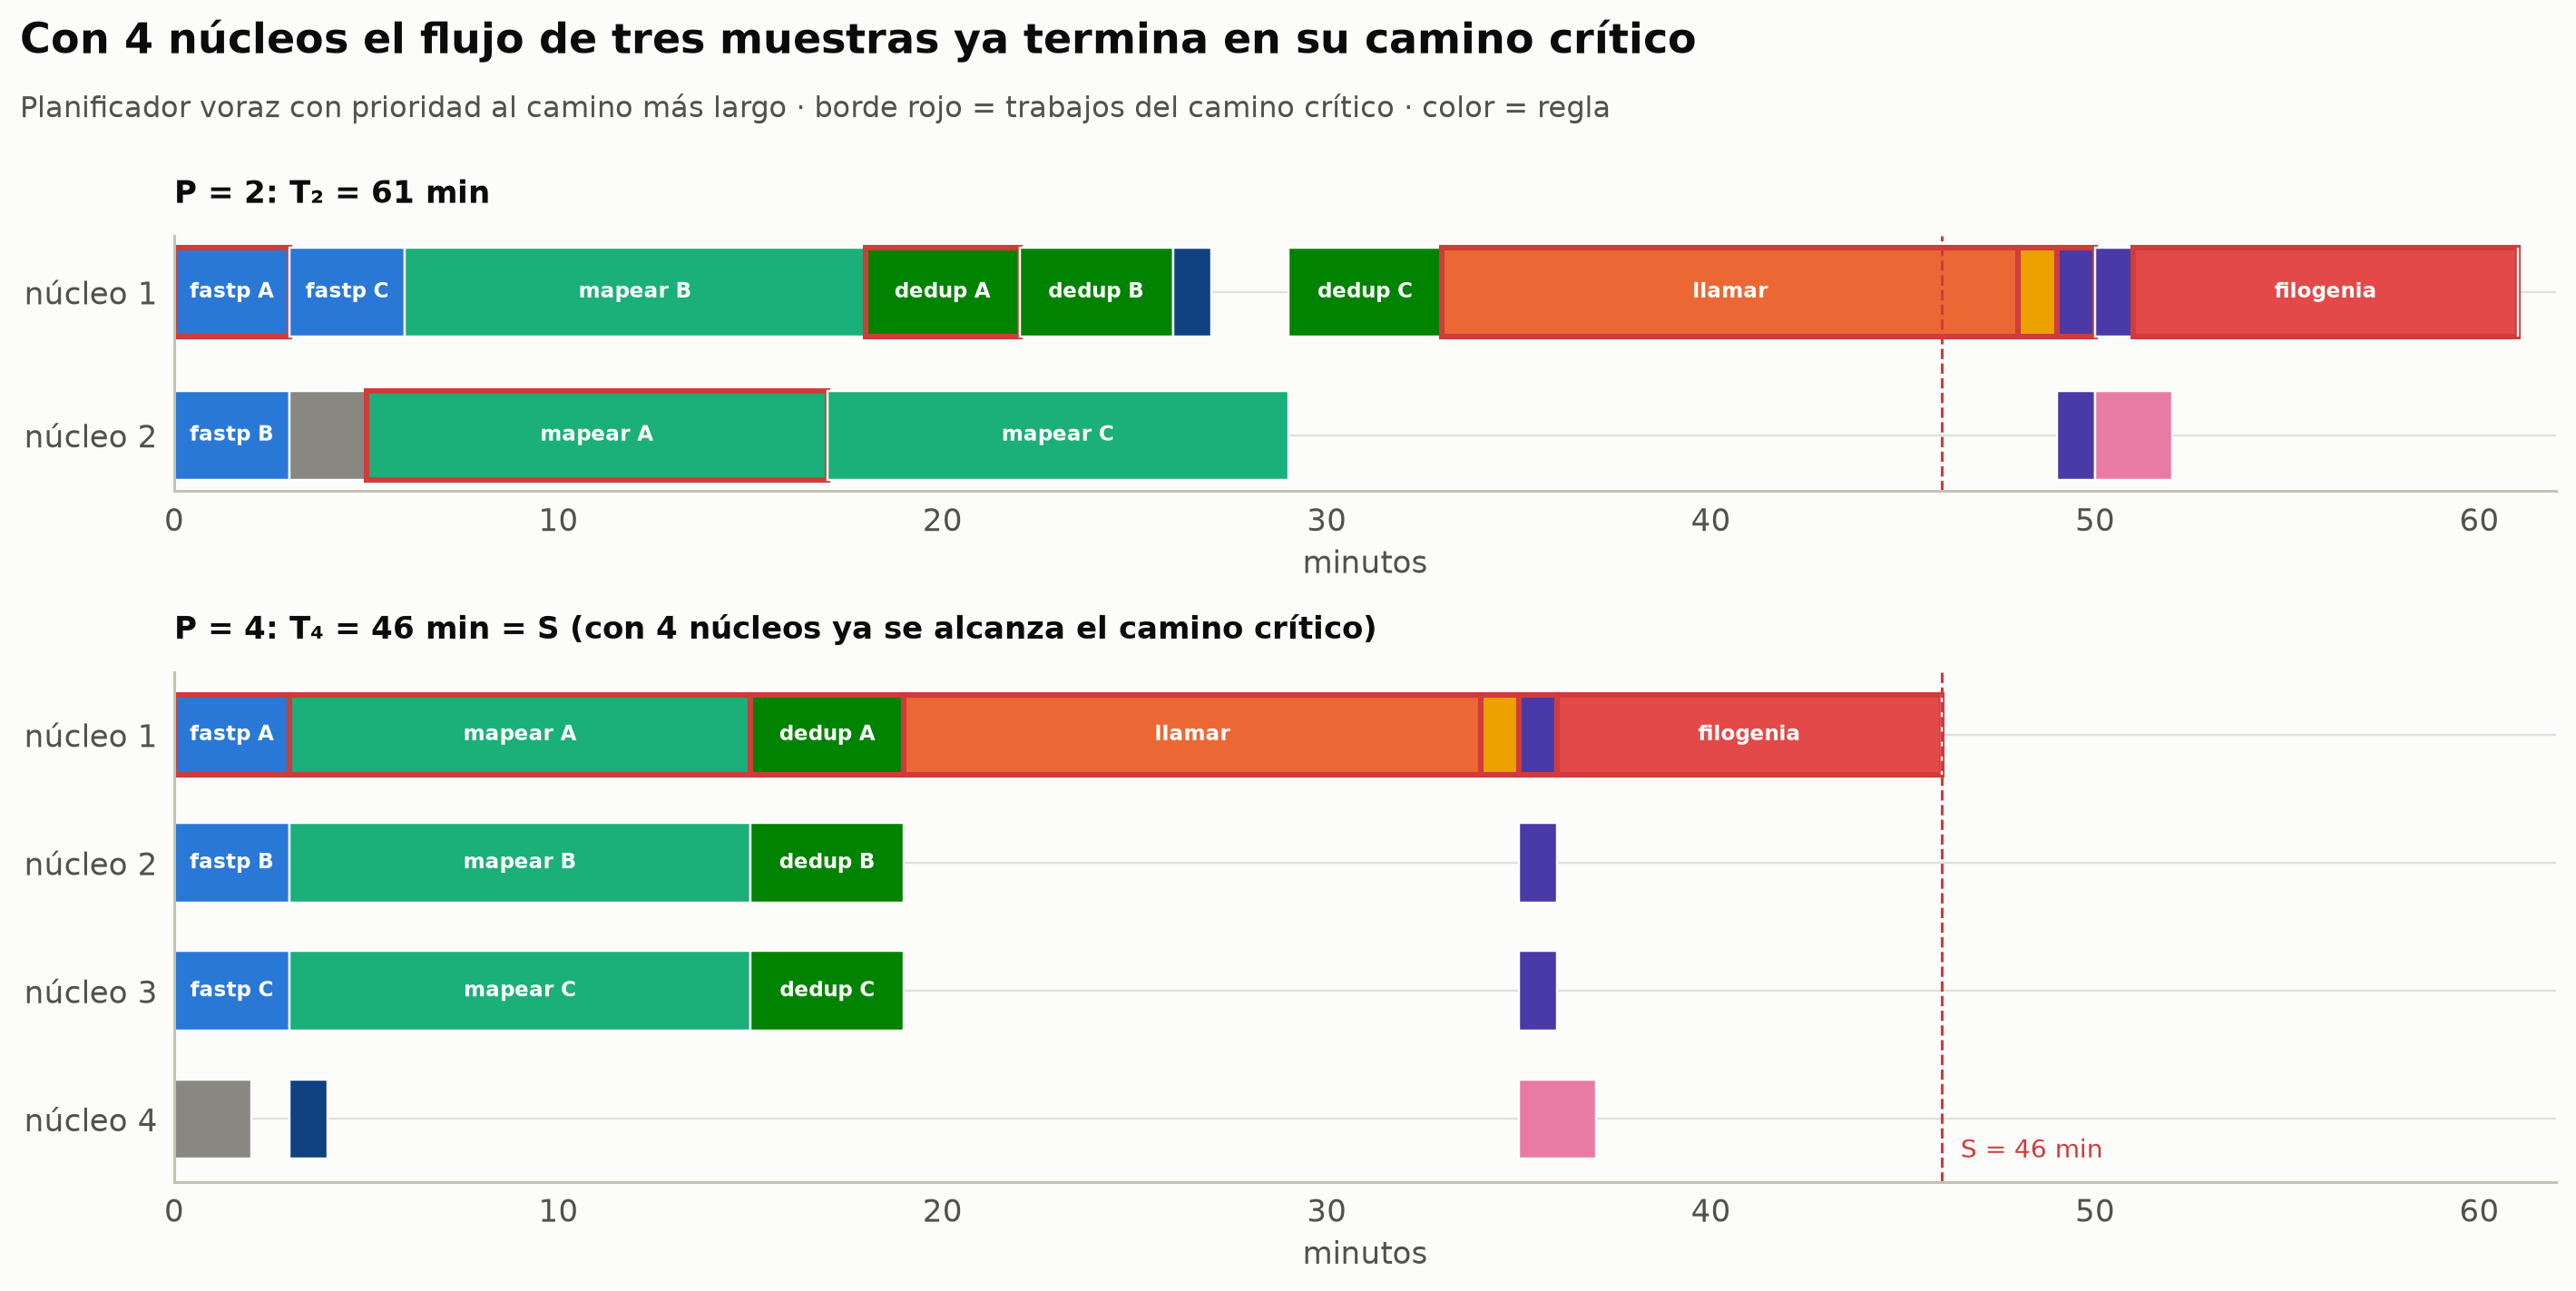

In [32]:
def draw_gantt(ax, gantt, P, upto=None, title=True):
    upto = math.inf if upto is None else upto
    crit = set(crit3)
    for v, c, a, b in gantt:
        if a >= upto:
            continue
        bb = min(b, upto)
        ax.barh(c, bb - a, left=a, height=0.62, color=RULE_COLOR[rule_of(v)],
                edgecolor="#d03b3b" if v in crit else "white", lw=2 if v in crit else 0.8)
        if bb - a >= 2.5:
            ax.text((a + bb) / 2, c, v.replace("_", " "), ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold")
    ax.set_yticks(range(P))
    ax.set_yticklabels([f"núcleo {c + 1}" for c in range(P)])
    ax.invert_yaxis()
    ax.set_xlim(0, max(b for *_, b in gantt) + 1)
    ax.set_xlabel("minutos")

T2, G2 = schedule(SUCC, T3, 2)
T4, G4 = schedule(SUCC, T3, 4)
fig, axes = plt.subplots(2, 1, figsize=(13, 5.8), gridspec_kw={"height_ratios": [2, 4]})
draw_gantt(axes[0], G2, 2)
draw_gantt(axes[1], G4, 4)
axes[0].set_title(f"P = 2: T₂ = {T2:.0f} min", loc="left", fontsize=11)
axes[1].set_title(f"P = 4: T₄ = {T4:.0f} min = S (con 4 núcleos ya se alcanza el camino crítico)", loc="left", fontsize=11)
for ax in axes:
    ax.axvline(S3, color="#d03b3b", ls="--", lw=1)
    ax.set_xlim(0, T2 + 1)
axes[1].text(S3 + 0.5, 3.3, "S = 46 min", color="#d03b3b", fontsize=9)
ec.fig_title(fig, "Con 4 núcleos el flujo de tres muestras ya termina en su camino crítico",
             "Planificador voraz con prioridad al camino más largo · borde rojo = trabajos del camino crítico · color = regla")
plt.tight_layout()
plt.show()

![El planificador voraz con 2 núcleos: cada vez que un núcleo queda libre toma el trabajo listo con el camino más largo hasta el final; abajo, la cola de trabajos listos.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-18-flujos-proyecto/18.1_gantt.gif)

*El planificador voraz con 2 núcleos: cada vez que un núcleo queda libre toma el trabajo listo con el camino más largo hasta el final; abajo, la cola de trabajos listos.*

In [33]:
events = sorted({0.0} | {b for *_, b in G2})
fig, ax = plt.subplots(figsize=(12.5, 3.6))

def update(k):
    ax.clear()
    now = events[k]
    draw_gantt(ax, G2, 2, upto=now + 1e-9)
    ax.axvline(now, color="#0b0b0b", lw=1)
    finished = {v for v, c, a, b in G2 if b <= now}
    started = {v for v, c, a, b in G2 if a <= now}
    ready = [v for v in SUCC if v not in started and all(u in finished for u in PRED[v])]
    ax.set_xlim(0, T2 + 1)
    ec.title(ax, f"t = {now:.0f} min · {len(finished)} de 19 trabajos terminados",
             "listos: " + (", ".join(canonical(ready)) if ready else "—"))

ec.animate(fig, update, frames=len(events), interval=700, name="18.1_gantt")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Veinticuatro muestras: dónde está el cuello de botella

Con $n=24$ el trabajo crece a $W=616$ min pero el camino crítico también ($S=151$ min), porque `llamar` ($6+3\cdot24=78$
min) y `filogenia` (52 min) crecen con $n$. La **ley de Amdahl** (1967) resume este fenómeno: si una fracción $s$ del tiempo
en serie no se puede paralelizar y el resto se reparte sin coste entre $P$ núcleos,

$$
\psi(P) = \frac{T_1}{T_P} = \frac{1}{s + \dfrac{1-s}{P}}\;\xrightarrow[P\to\infty]{}\;\frac{1}{s}. \tag{18.9}
$$

Gustafson (1988) replicó que en la práctica no se resuelve el mismo problema más deprisa sino uno **más grande** en el mismo
tiempo, con aceleración escalada $\psi_G(P) = s + (1-s)P = P - s(P-1)$ (18.10). Y Karp y Flatt (1990) propusieron estimar la
fracción serial **efectiva** de una aceleración medida:

$$
e(P) = \frac{1/\psi(P) - 1/P}{1 - 1/P}. \tag{18.11}
$$

| Símbolo | Significado |
|---|---|
| $s$ | fracción serial del trabajo ($0<s\le 1$) |
| $P$ | número de núcleos (o de trabajos simultáneos) |
| $\psi(P)$ | aceleración (*speedup*) con $P$ núcleos respecto de uno |
| $\psi_G(P)$ | aceleración escalada de Gustafson |
| $e(P)$ | fracción serial efectiva de Karp-Flatt |

**A mano:** con $s=0{,}1$, $\psi(8) = 1/(0{,}1 + 0{,}9/8) = 4{,}71$, $\psi(64)=8{,}77$ y nunca más de 10; en cambio
$\psi_G(64) = 64 - 0{,}1\cdot 63 = 57{,}7$. Ambas leyes son correctas: responden a preguntas distintas. Si $e$ se mantiene
constante al aumentar $P$, el límite es una parte serial genuina; si crece, el problema es la coordinación.

Simulemos el planificador sobre el grafo de 24 muestras, con el llamado como un único trabajo y dividido en 24 regiones del
genoma (*scatter-gather*: 24 trabajos de $78/24$ min y una concatenación de 1 min).

In [34]:
S24_names = [f"m{i:02d}" for i in range(24)]
G24, T24 = build_dag(S24_names)
G24s, T24s = build_dag(S24_names, regions=24)
W24, S24, crit24 = work_span(G24, T24)
W24s, S24s, _ = work_span(G24s, T24s)
print(f"n = 24, llamado único : W = {W24} · S = {S24} · W/S = {W24 / S24:.2f}")
print(f"n = 24, 24 regiones   : W = {W24s:.1f} · S = {S24s:.2f} · W/S = {W24s / S24s:.2f}")
print(f"llamar + filogenia = {T24['llamar'] + T24['filogenia']} de los {S24} min del camino crítico")

Ps = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]
base = [W24 / schedule(G24, T24, P)[0] for P in Ps]
scat = [W24s / schedule(G24s, T24s, P)[0] for P in Ps]

def karp_flatt(psi, P):
    return (1 / psi - 1 / P) / (1 - 1 / P)

def fit_amdahl(col):
    """Fracción serial s (rejilla de 0,001) que mejor ajusta una curva de aceleración (mínimos cuadrados)."""
    grid = np.arange(1, 1000) / 1000
    err = [sum((1 / (s + (1 - s) / P) - v) ** 2 for P, v in zip(Ps, col)) for s in grid]
    return grid[int(np.argmin(err))]

sb, ss = fit_amdahl(base), fit_amdahl(scat)
speed = pd.DataFrame({"P": Ps, "ψ llamado único": np.round(base, 2), "ψ 24 regiones": np.round(scat, 2),
                      "e Karp-Flatt (único)": [round(karp_flatt(a, P), 3) if P > 1 else None for a, P in zip(base, Ps)],
                      "e Karp-Flatt (regiones)": [round(karp_flatt(b, P), 3) if P > 1 else None for b, P in zip(scat, Ps)]})
display(speed.set_index("P").T)
print(f"s de Amdahl ajustada: llamado único {sb:.3f} (límite {1 / sb:.1f}) · 24 regiones {ss:.3f} (límite {1 / ss:.1f})")

n = 24, llamado único : W = 616 · S = 151 · W/S = 4.08
n = 24, 24 regiones   : W = 617.0 · S = 77.25 · W/S = 7.99
llamar + filogenia = 130 de los 151 min del camino crítico


P,1,2,3,4,6,8,12,16,24,32,48,64
ψ llamado único,1.0,1.650,2.100,2.430,2.890,3.190,3.560,3.710,4.030,4.080,4.080,4.080
ψ 24 regiones,1.0,1.840,2.550,3.160,4.140,4.910,6.020,6.460,7.790,7.990,7.990,7.990
e Karp-Flatt (único),NaN,0.211,0.213,0.214,0.215,0.215,0.215,0.221,0.216,0.221,0.229,0.233
e Karp-Flatt (regiones),NaN,0.086,0.088,0.089,0.090,0.090,0.090,0.098,0.091,0.097,0.107,0.111


s de Amdahl ajustada: llamado único 0.223 (límite 4.5) · 24 regiones 0.102 (límite 9.8)


> 🔎 **Qué observamos.** Las cifras del libro: aceleraciones de 3,19 con 8 núcleos, 3,71 con 16 y 4,08 desde 32. La
> fracción serial de Karp-Flatt con 16 núcleos es $e=0{,}221$: más de una quinta parte del tiempo es serial, y está en
> `llamar` y `filogenia` (130 de los 151 min del camino crítico). Dividiendo el llamado en 24 regiones el camino crítico cae a
> 77,25 min, el paralelismo sube a 7,99 y la aceleración con 16 núcleos pasa de 3,71 a **6,46** ($e=0{,}098$). Explore la
> figura interactiva: el *hover* da, para cada $P$, el tiempo total, la eficiencia $\psi/P$ (qué fracción de los núcleos
> pagados trabaja) y la fracción serial efectiva.

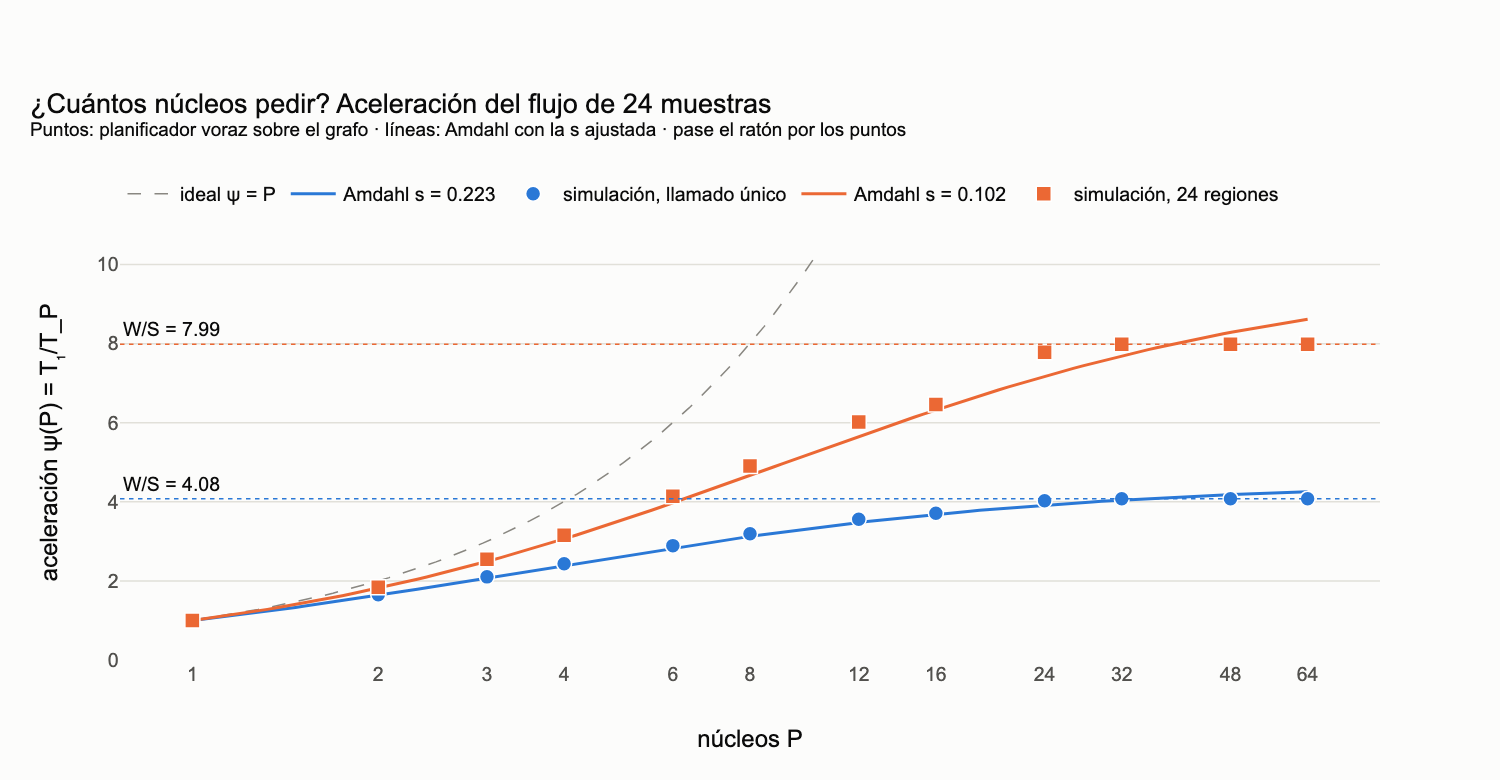

In [35]:
Pgrid = np.geomspace(1, 64, 120)
fig = go.Figure()
fig.add_trace(go.Scatter(x=Pgrid[Pgrid <= 10.5], y=Pgrid[Pgrid <= 10.5], mode="lines", name="ideal ψ = P",
                         line=dict(color="#898781", dash="dash", width=1), hoverinfo="skip"))
for col, s_fit, W_, name, colr, sym in [(base, sb, W24, "llamado único", ec.BLUE, "circle"),
                                        (scat, ss, W24s, "24 regiones", ec.ORANGE, "square")]:
    fig.add_trace(go.Scatter(x=Pgrid, y=1 / (s_fit + (1 - s_fit) / Pgrid), mode="lines",
                             name=f"Amdahl s = {s_fit:.3f}", line=dict(color=colr, width=2), hoverinfo="skip"))
    hover = [f"<b>{name}</b> · P = {P} núcleos<br>ψ = {v:.2f} (eficiencia ψ/P = {v / P:.0%})"
             f"<br>T_P = {W_ / v:.0f} min ({W_ / v / 60:.2f} h) frente a T₁ = {W_:.0f} min"
             + (f"<br>Karp-Flatt e = {karp_flatt(v, P):.3f}" if P > 1 else "") for P, v in zip(Ps, col)]
    fig.add_trace(go.Scatter(x=Ps, y=col, mode="markers", name=f"simulación, {name}",
                             marker=dict(color=colr, size=10, symbol=sym, line=dict(color="white", width=1)),
                             hovertext=hover, hoverinfo="text"))
for y, colr, txt in [(W24 / S24, ec.BLUE, f"W/S = {W24 / S24:.2f}"), (W24s / S24s, ec.ORANGE, f"W/S = {W24s / S24s:.2f}")]:
    fig.add_hline(y=y, line=dict(color=colr, dash="dot", width=1), annotation_text=txt, annotation_position="top left")
fig.update_layout(title="¿Cuántos núcleos pedir? Aceleración del flujo de 24 muestras<br><sup>Puntos: planificador voraz "
                        "sobre el grafo · líneas: Amdahl con la s ajustada · pase el ratón por los puntos</sup>",
                  xaxis=dict(type="log", title="núcleos P", tickvals=Ps, ticktext=[str(p) for p in Ps]),
                  yaxis=dict(title="aceleración ψ(P) = T₁/T_P", range=[0, 11]), height=520,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=150))
fig.show()

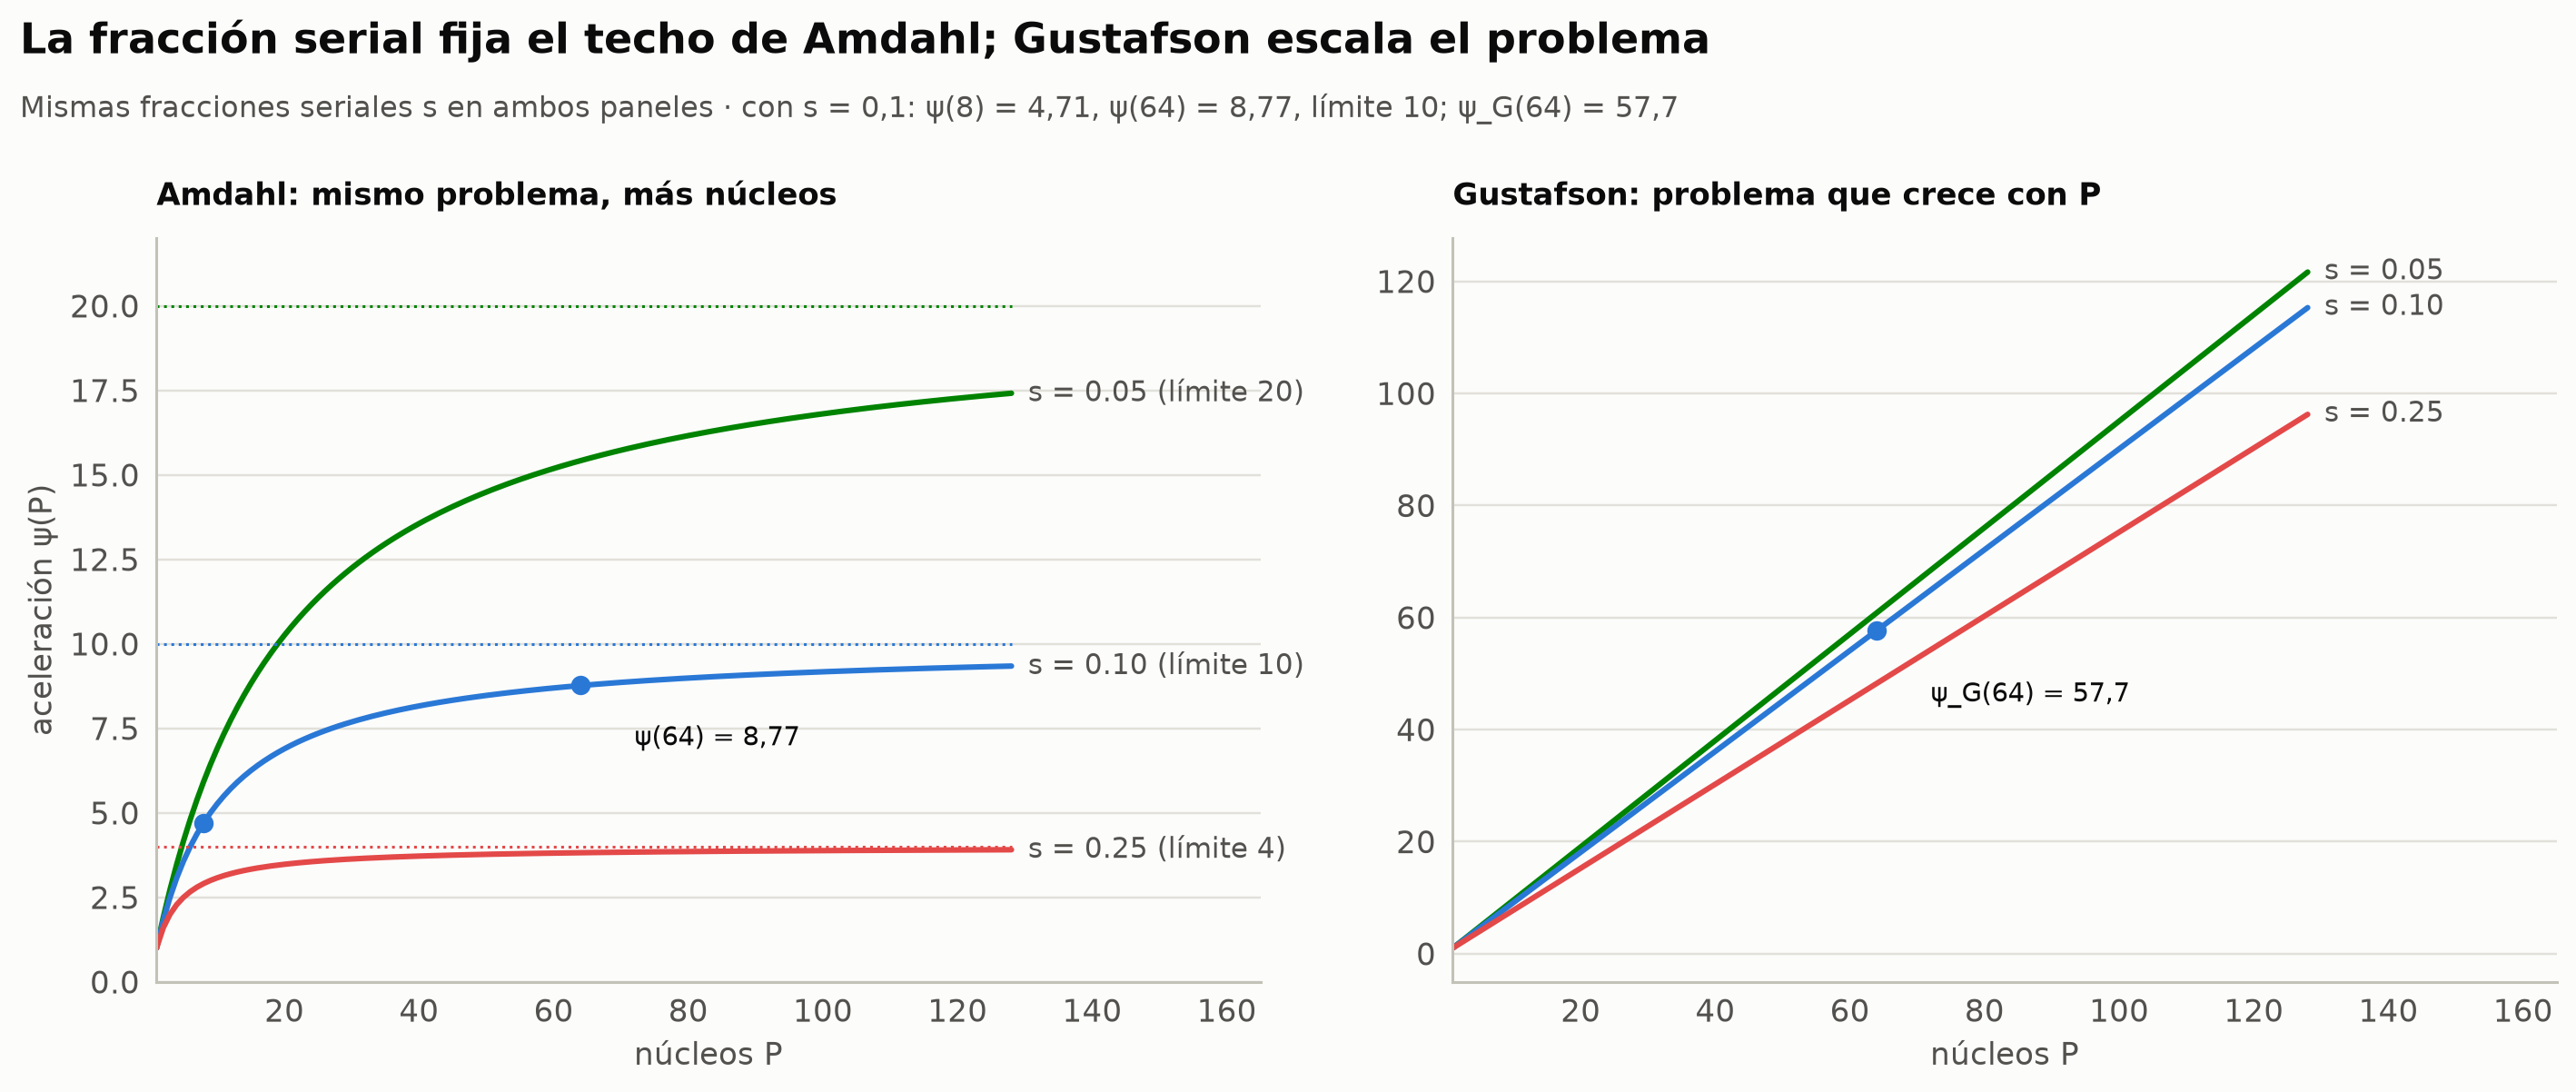

In [36]:
P = np.arange(1, 129)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
for s_, colr in zip((0.05, 0.10, 0.25), (ec.GREEN, ec.BLUE, ec.RED)):
    axes[0].plot(P, 1 / (s_ + (1 - s_) / P), color=colr, lw=2)
    axes[0].hlines(1 / s_, 1, 128, color=colr, ls=":", lw=1)
    ec.label_end(axes[0], P[-1], 1 / (s_ + (1 - s_) / P[-1]), f"s = {s_:.2f} (límite {1 / s_:.0f})")
    axes[1].plot(P, P - s_ * (P - 1), color=colr, lw=2)
    ec.label_end(axes[1], P[-1], P[-1] - s_ * (P[-1] - 1), f"s = {s_:.2f}")
axes[0].scatter([8, 64], [4.71, 8.77], color=ec.BLUE, zorder=3)
axes[0].annotate("ψ(64) = 8,77", (64, 8.77), xytext=(72, 7.0), fontsize=9.5, arrowprops=dict(arrowstyle="-", color="#898781"))
axes[1].scatter([64], [57.7], color=ec.BLUE, zorder=3)
axes[1].annotate("ψ_G(64) = 57,7", (64, 57.7), xytext=(72, 45), fontsize=9.5, arrowprops=dict(arrowstyle="-", color="#898781"))
axes[0].set_ylim(0, 22)
for ax in axes:
    ax.set_xlabel("núcleos P")
    ax.set_xlim(1, 165)
axes[0].set_ylabel("aceleración ψ(P)")
axes[0].set_title("Amdahl: mismo problema, más núcleos", loc="left", fontsize=11)
axes[1].set_title("Gustafson: problema que crece con P", loc="left", fontsize=11)
ec.fig_title(fig, "La fracción serial fija el techo de Amdahl; Gustafson escala el problema",
             "Mismas fracciones seriales s en ambos paneles · con s = 0,1: ψ(8) = 4,71, ψ(64) = 8,77, límite 10; ψ_G(64) = 57,7")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Con Amdahl, cada curva se aplana hacia su techo $1/s$: con 25 % de trabajo serial, ni mil núcleos
> dan más de 4×. Con Gustafson la aceleración escalada crece casi como $P$. En bioinformática se ven las dos: al añadir
> muestras crece sobre todo la parte paralela (Gustafson), pero cada paso conjunto que las reúne (llamado, filogenia,
> normalización de una matriz de conteos) añade un tramo serial que limita una ejecución concreta (Amdahl).

> 💡 **Idea clave.** El tiempo de un flujo en paralelo está entre $\max(W/P,S)$ y $W/P+S$. Más núcleos sólo ayudan mientras
> $W/P$ domine; después, la única forma de ir más rápido es **acortar el camino crítico**. Encontrar el orden óptimo es
> NP-difícil para $P\ge2$, pero cualquier planificador voraz queda a menos de un factor 2 del óptimo, porque
> $W/P+S\le 2\max(W/P,S)$. En la práctica pesan más la espera en la cola del clúster, el sistema de archivos compartido y el
> arranque de contenedores: agrupe los trabajos diminutos (`group` en Snakemake).

> ✅ **Compruebe su comprensión.** Un colega pide 64 núcleos para el flujo de 24 muestras con llamado único. ¿Qué le
> responde? *(Respuesta: desde 32 núcleos la aceleración ya es $W/S=4{,}08$; con 16 se obtiene 3,71. Mejor pedir 16 y
> dividir el llamado por regiones, lo que lleva la aceleración con esos mismos 16 núcleos a 6,46.)*

## 11. Buenas prácticas y principios FAIR

Un gestor de flujos resuelve la parte mecánica de la reproducibilidad, pero no sustituye a los hábitos. Sandve *et al.*
(2013) los condensaron en **diez reglas**; revisemos nuestro mini-proyecto `flujo181` con ellas.

| # | Regla (Sandve *et al.*, 2013) | ¿Cómo la cumple `flujo181`? |
|---|---|---|
| 1 | registrar cómo se produjo cada resultado | el *Snakefile* **es** el registro; `.snakemake/` guarda metadatos por archivo |
| 2 | evitar pasos manuales de manipulación de datos | el reparto en A/B/C y la anotación son código, no hojas de cálculo |
| 3 | archivar las versiones exactas de los programas | `procedencia.json` (y, en producción, `envs/*.yaml` con versiones exactas) |
| 4 | control de versiones de todos los *scripts* | pendiente: `git init` y un *commit* por cambio (Lección 18.2) |
| 5 | guardar resultados intermedios en formatos estándar | BAM, BCF, VCF, FASTA, TSV |
| 6 | anotar las semillas de todo análisis aleatorio | el reparto es determinista ($i \bmod 3$); no hay azar |
| 7 | guardar los datos crudos detrás de cada gráfica | `resultados/anotado.tsv` alimenta la figura de las SNV |
| 8 | salidas jerárquicas que permitan ver los detalles | `logs/`, `qc/`, `mapeo/`, `variantes/`, `resultados/` |
| 9 | conectar cada afirmación con el resultado que la sustenta | este notebook cita la tabla o la figura de cada cifra |
| 10 | acceso público a *scripts*, ejecuciones y resultados | el curso está en GitHub con licencia MIT |

Los datos y resultados, además, deben ser **FAIR** (Wilkinson *et al.*, 2016):

| Principio | Significa | En nuestro caso |
|---|---|---|
| **F**indable (localizable) | identificador persistente y metadatos ricos, indexados | SRR2584863 (SRA), NC_012967.1 (RefSeq) |
| **A**ccessible (accesible) | recuperable por su identificador con un protocolo abierto | HTTPS/FTP del NCBI y del ENA |
| **I**nteroperable | formatos y vocabularios compartidos | FASTQ, BAM, VCF 4.2, GFF/TSV con *locus tags* |
| **R**eusable (reutilizable) | licencia clara, procedencia detallada, estándares de la comunidad | `procedencia.json` + licencia + `README` |

Un detalle que suele pasarse por alto: los principios se dirigen tanto a personas como a **máquinas**. Un conjunto de datos es
FAIR cuando un programa puede encontrarlo, descargarlo y entenderlo sin intervención humana; un flujo bien escrito es la
contraparte computacional: describe, de forma ejecutable, cómo se pasa de los datos a los resultados. Wilson *et al.* (2017)
proponen el mínimo "suficientemente bueno" para quien no es informático de profesión: datos crudos intactos, nombres de
archivo informativos, funciones pequeñas, control de versiones y un `README` que explique cómo reproducirlo todo.

## 12. Ejercicios

**Ejercicio 1 (Kahn con pila).** Cambie la cola FIFO de `orden_topologico` por una pila (LIFO: `pop()` en lugar de
`popleft()`). Obtenga el orden para el grafo del libro, compruebe que respeta (18.1) y diga en qué posición sale `llamar`
con cada versión.

**Ejercicio 2 (tocar la referencia).** La referencia `ref/REL606.fa` pesa 4,6 MB. Prediga, con los descendientes de `bwa_index`
en el DAG de Snakemake (`SMK`), cuántos trabajos se rehacen si se hace `touch` sobre ella, y compruébelo con `snakemake -n`. ¿Por
qué aquí el `touch` sí dispara recálculos y en la sección 5 no?

**Ejercicio 3 (canales).** En el `main.nf` del libro, suponga que por error `FILTRAR.out` fuera un canal de **cola** con un
elemento. ¿Cuántas tareas de `CONSENSO` se ejecutarían con 3 identificadores? Verifíquelo con `run_process` y corríjalo.

**Ejercicio 4 (Amdahl y Gustafson).** Con $s=0{,}05$ calcule $\psi(8)$, $\psi(64)$, el límite y $\psi_G(64)$. ¿Cuántos
núcleos hacen falta, como mínimo, para una aceleración de 10?

**Ejercicio 5 (scatter-gather).** Repita el análisis de 24 muestras dividiendo el llamado en 8 regiones en lugar de 24.
¿Cuánto valen $S$, $W/S$ y la aceleración con 16 núcleos? ¿Cuál es ahora el trabajo del camino crítico que más pesa?

In [37]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
def orden_topologico_pila(sucesores):
    grado = {v: 0 for v in sucesores}
    for hijos in sucesores.values():
        for u in hijos:
            grado[u] += 1
    pila = [v for v, g in grado.items() if g == 0]
    orden = []
    while pila:
        v = pila.pop()                       # LIFO
        orden.append(v)
        for u in sucesores[v]:
            grado[u] -= 1
            if grado[u] == 0:
                pila.append(u)
    if len(orden) < len(grado):
        raise ValueError("ciclo")
    return orden

succ_c = {v: canonical(SUCC[v]) for v in NODES}
fifo, lifo = orden_topologico(succ_c), orden_topologico_pila(succ_c)
pos_l = {v: i for i, v in enumerate(lifo)}
print("LIFO:", lifo)
print("¿respeta (18.1)?", all(pos_l[u] < pos_l[v] for u in SUCC for v in SUCC[u]))
for v in ("multiqc", "llamar", "anotar"):
    print(f"{v:8s} sale en la posición {fifo.index(v) + 1:2d} (FIFO) y {lifo.index(v) + 1:2d} (LIFO)")
print("La pila avanza 'en profundidad' (termina una muestra antes de empezar otra); la cola, 'en anchura'.")

LIFO: ['fastp_C', 'fastp_B', 'fastp_A', 'multiqc', 'bwa_index', 'mapear_C', 'dedup_C', 'mapear_B', 'dedup_B', 'mapear_A', 'dedup_A', 'llamar', 'filtrar', 'consenso_C', 'consenso_B', 'consenso_A', 'filogenia', 'anotar', 'all']
¿respeta (18.1)? True
multiqc  sale en la posición  8 (FIFO) y  4 (LIFO)
llamar   sale en la posición 12 (FIFO) y 12 (LIFO)
anotar   sale en la posición 14 (FIFO) y 18 (LIFO)
La pila avanza 'en profundidad' (termina una muestra antes de empezar otra); la cola, 'en anchura'.


In [38]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
pred_ref = {"bwa_index"} | descendants(SMK, "bwa_index")
pred_ref.discard("all")
print(f"predicción con (18.3): {len(pred_ref)} trabajos → {', '.join(sorted(pred_ref))}")
time.sleep(1.1)
os.utime(f"{W}/ref/REL606.fa")
st_ref, _ = plan()
print(f"snakemake -n: {sum(st_ref.values())} trabajos → {st_ref}")
print("""
1) La referencia pesa más de 1 MB (--max-checksum-file-size): Snakemake no calcula su suma y se fía de la fecha, así
   que el touch es indistinguible de un cambio real. Los 14 trabajos predichos son la cifra del libro para 'cambiar bwa_index'.
2) Snakemake planea 4 más: los tres qc y el informe. ¿Por qué? Los mapeos deben repetirse y necesitan las lecturas
   limpias, que eran temp() y ya se borraron: hay que regenerarlas, y al rehacer qc cambian sus JSON y con ellos el informe.
   temp() ahorra disco a cambio de recálculo: márquelo sólo en intermedios baratos de regenerar.""")
smk("--touch --cores 1", quiet=True)          # marca las salidas como al día sin recalcular
print("tras --touch:", sum(plan()[0].values()), "trabajos pendientes")

predicción con (18.3): 14 trabajos → anotar, bwa_index, consenso_A, consenso_B, consenso_C, dedup_A, dedup_B, dedup_C, distancias, filtrar, llamar, mapear_A, mapear_B, mapear_C


snakemake -n: 18 trabajos → {'bwa_index': 1, 'qc': 3, 'informe': 1, 'mapear': 3, 'dedup': 3, 'llamar': 1, 'filtrar': 1, 'anotar': 1, 'consenso': 3, 'distancias': 1}

1) La referencia pesa más de 1 MB (--max-checksum-file-size): Snakemake no calcula su suma y se fía de la fecha, así
   que el touch es indistinguible de un cambio real. Los 14 trabajos predichos son la cifra del libro para 'cambiar bwa_index'.
2) Snakemake planea 4 más: los tres qc y el informe. ¿Por qué? Los mapeos deben repetirse y necesitan las lecturas
   limpias, que eran temp() y ya se borraron: hay que regenerarlas, y al rehacer qc cambian sus JSON y con ellos el informe.
   temp() ahorra disco a cambio de recálculo: márquelo sólo en intermedios baratos de regenerar.


tras --touch: 0 trabajos pendientes


In [39]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
ids = ["A", "B", "C"]
print("❌ VCF por canal de cola:")
run_process("CONSENSO", ids, [("filtrado.vcf.gz", "filtrado.vcf.gz.tbi")], Value("REL606.fa"))
print("✅ VCF por canal de valor (lo que ocurre de verdad, porque LLAMAR recibe collect()):")
run_process("CONSENSO", ids, Value(("filtrado.vcf.gz", "filtrado.vcf.gz.tbi")), Value("REL606.fa"))
print("Si hiciera falta forzarlo: FILTRAR.out.first() o .collect() convierten una cola en un valor.")

❌ VCF por canal de cola:
CONSENSO: 1 tarea(s) → ['A']
✅ VCF por canal de valor (lo que ocurre de verdad, porque LLAMAR recibe collect()):
CONSENSO: 3 tarea(s) → ['A', 'B', 'C']
Si hiciera falta forzarlo: FILTRAR.out.first() o .collect() convierten una cola en un valor.


In [40]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
s_ = 0.05
amdahl = lambda P: 1 / (s_ + (1 - s_) / P)
print(f"ψ(8) = {amdahl(8):.2f} · ψ(64) = {amdahl(64):.2f} · límite 1/s = {1 / s_:.0f} · ψ_G(64) = {64 - s_ * 63:.2f}")
# 1/(s + (1-s)/P) = 10  ⇒  (1-s)/P = 0.1 - s  ⇒  P = (1-s)/(0.1-s)
print(f"P mínimo para ψ = 10: (1-s)/(0,1-s) = {(1 - s_) / (0.1 - s_):.0f} núcleos;",
      "comprobación ψ(19) =", round(amdahl(19), 2))

ψ(8) = 5.93 · ψ(64) = 15.42 · límite 1/s = 20 · ψ_G(64) = 60.85
P mínimo para ψ = 10: (1-s)/(0,1-s) = 19 núcleos; comprobación ψ(19) = 10.0


In [41]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
G8, T8 = build_dag(S24_names, regions=8)
W8, S8, crit8 = work_span(G8, T8)
psi16 = W8 / schedule(G8, T8, 16)[0]
print(f"8 regiones: W = {W8:.1f} · S = {S8:.2f} · W/S = {W8 / S8:.2f} · ψ(16) = {psi16:.2f}")
print("camino crítico:", " → ".join(crit8))
heavy = max(crit8, key=lambda v: T8[v])
print(f"trabajo más pesado del camino crítico: {heavy} ({T8[heavy]:.1f} min) → paralelizar la filogenia (IQ-TREE -T)")

8 regiones: W = 617.0 · S = 83.75 · W/S = 7.37 · ψ(16) = 6.25
camino crítico: fastp_m00 → mapear_m00 → dedup_m00 → region_0 → concat → filtrar → consenso_m00 → filogenia
trabajo más pesado del camino crítico: filogenia (52.0 min) → paralelizar la filogenia (IQ-TREE -T)


## 📌 Resumen

- Un análisis es un **grafo acíclico dirigido** de trabajos $G=(V,E)$; existe un orden topológico **si y sólo si** no hay
  ciclos. El flujo del libro con tres muestras tiene 19 trabajos, 26 aristas y 8 rondas de anchos $4,4,3,1,1,4,1,1$.
- El **algoritmo de Kahn** mantiene grados de entrada residuales $d^-(v)$ y una cola $Q$ de trabajos listos: ordena en
  $O(|V|+|E|)$ y detecta ciclos gratis. La cola $Q$ es, literalmente, lo que un planificador puede lanzar en cada instante.
- `make` decide qué rehacer con la ecuación (18.3): un cambio se propaga a **todos los descendientes y a nadie más**
  (11, 6, 14 y 1 trabajos en los cuatro escenarios del libro). Con Snakemake sobre datos reales del LTEE confirmamos los
  dos primeros (11 y 6); al tocar la referencia rehízo 18, los 14 del libro más 4 que obligan a regenerar los `temp()`, y
  el caso de 1 trabajo no lo ejecutamos.
- **Snakemake** infiere el grafo **hacia atrás** desde los archivos pedidos mediante comodines ($\sigma$ de la ecuación
  18.4); **Nextflow** lo desenvuelve **hacia adelante** con canales de cola y de valor ($n_{\text{tareas}}=\min_i|c_i|$).
- La reproducibilidad tiene capas: código (Git), herramientas (Bioconda con versiones exactas), sistema (contenedores
  fijados por *digest*), datos (identificadores y SHA-256) y azar (semillas).
- Las claves de caché con *hash* (ecuación 18.6) evitan los falsos positivos de las fechas y detectan cambios de parámetros
  y versiones que las fechas no ven.
- $\max(W/P,S)\le T_P\le W/P+S$: el paralelismo máximo es $W/S$. Antes de pedir más núcleos, **busque el camino crítico**
  (con 24 muestras, dividir el llamado por regiones lleva la aceleración con 16 núcleos de 3,71 a 6,46).
- Las diez reglas de Sandve y los principios **FAIR** convierten un flujo que funciona en un resultado que otros (y usted
  dentro de un año) pueden encontrar, ejecutar y reutilizar.

## 📚 Lecturas recomendadas

- Köster, J. y Rahmann, S. (2012). Snakemake—a scalable bioinformatics workflow engine. *Bioinformatics* 28(19):2520–2522.
  https://doi.org/10.1093/bioinformatics/bts480
- Mölder, F. *et al.* (2021). Sustainable data analysis with Snakemake. *F1000Research* 10:33.
  https://doi.org/10.12688/f1000research.29032.2
- Di Tommaso, P. *et al.* (2017). Nextflow enables reproducible computational workflows. *Nature Biotechnology* 35:316–319.
  https://doi.org/10.1038/nbt.3820
- Ewels, P. A. *et al.* (2020). The nf-core framework for community-curated bioinformatics pipelines. *Nature Biotechnology*
  38:276–278. https://doi.org/10.1038/s41587-020-0439-x
- Wratten, L., Wilm, A. y Göke, J. (2021). Reproducible, scalable, and shareable analysis pipelines with bioinformatics
  workflow managers. *Nature Methods* 18:1161–1168. https://doi.org/10.1038/s41592-021-01254-9
- Crusoe, M. R. *et al.* (2022). Methods included: Standardizing computational reuse and portability with the Common
  Workflow Language. *Communications of the ACM* 65(6):54–63. https://doi.org/10.1145/3486897
- Kahn, A. B. (1962). Topological sorting of large networks. *Communications of the ACM* 5(11):558–562.
  https://doi.org/10.1145/368996.369025
- Feldman, S. I. (1979). Make—a program for maintaining computer programs. *Software: Practice and Experience* 9(4):255–265.
  https://doi.org/10.1002/spe.4380090402
- The Bioconda Team, Grüning, B. *et al.* (2018). Bioconda: sustainable and comprehensive software distribution for the life
  sciences. *Nature Methods* 15:475–476. https://doi.org/10.1038/s41592-018-0046-7
- Grüning, B. *et al.* (2018). Practical computational reproducibility in the life sciences. *Cell Systems* 6(6):631–635.
  https://doi.org/10.1016/j.cels.2018.03.014
- Kurtzer, G. M., Sochat, V. y Bauer, M. W. (2017). Singularity: Scientific containers for mobility of compute. *PLOS ONE*
  12(5):e0177459. https://doi.org/10.1371/journal.pone.0177459
- da Veiga Leprevost, F. *et al.* (2017). BioContainers: an open-source and community-driven framework for software
  standardization. *Bioinformatics* 33(16):2580–2582. https://doi.org/10.1093/bioinformatics/btx192
- Amdahl, G. M. (1967). Validity of the single processor approach to achieving large scale computing capabilities. *AFIPS
  Spring Joint Computer Conference*. https://doi.org/10.1145/1465482.1465560
- Gustafson, J. L. (1988). Reevaluating Amdahl's law. *Communications of the ACM* 31(5):532–533.
  https://doi.org/10.1145/42411.42415
- Karp, A. H. y Flatt, H. P. (1990). Measuring parallel processor performance. *Communications of the ACM* 33(5):539–543.
  https://doi.org/10.1145/78607.78614
- Sandve, G. K. *et al.* (2013). Ten simple rules for reproducible computational research. *PLoS Computational Biology*
  9(10):e1003285. https://doi.org/10.1371/journal.pcbi.1003285
- Wilson, G. *et al.* (2017). Good enough practices in scientific computing. *PLOS Computational Biology* 13(6):e1005510.
  https://doi.org/10.1371/journal.pcbi.1005510
- Wilkinson, M. D. *et al.* (2016). The FAIR Guiding Principles for scientific data management and stewardship. *Scientific
  Data* 3:160018. https://doi.org/10.1038/sdata.2016.18
- Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature* 536:165–170.
  https://doi.org/10.1038/nature18959

**Siguiente lección:** 18.2 · Proyecto integrador, donde este flujo crece hasta un proyecto completo con estructura de
directorios, pruebas, informe reproducible y rúbrica.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)